In [1]:
import sys
import importlib
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import random
import optuna
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
from sklearn.metrics import r2_score, mean_squared_error
base_path = "../src/"
sys.path.append(base_path)
import models
import train
from losses import *

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
#datafilename='../../DATA/data_L25LH_TNG.hdf5'
datafilename='../../DATA/data_L50_TNG_v3.hdf5'
with h5py.File(datafilename, 'r') as f:
    print("Datasets available:")
    for key in f.keys():
        print(key)

with h5py.File(datafilename, 'r') as f:
    #Parameters = f['Parameters'][0, :1024].T.reshape(-1, 1)
    Parameters = f['Parameters'][:, :1024].T
#logflag = np.array([False])
#logflag = np.array([False, False, True, True, True, True])
logflag = np.array([False, False, True, True, True, True, False, False, False, True, True, False, False, True, False, True, False, True, True, False, False, True, True, True, True, True, True, False, True, False, True, False, False, False, True])
logflag = logflag[:Parameters.shape[1]]
origParameters = Parameters
if not np.all(Parameters[:, logflag] > 0):
    raise ValueError("Some values to be logged are non-positive.")
PartiallyLoggedParameters = Parameters.copy()
PartiallyLoggedParameters[:, logflag] = np.log(PartiallyLoggedParameters[:, logflag])
means = PartiallyLoggedParameters.mean(axis=0)
stds = PartiallyLoggedParameters.std(axis=0)
Parameters = (PartiallyLoggedParameters - means) / stds
#print(Parameters.shape)
#print(Parameters.dtype)
#print(Parameters.min(axis=0))
#print(Parameters.max(axis=0))

with h5py.File(datafilename, 'r') as f:
    Ms_Mh_s90 = f['Ms_Mh_s90'][:].T
    Ms_Mh_s61 = f['Ms_Mh_s61'][:].T
    MBH_Mh_s90 = f['MBH_Mh_s90'][:].T
    MBH_Mh_s61 = f['MBH_Mh_s61'][:].T
    Mg_Mh_s90 = f['Mg_Mh_s90'][:].T
    Mg_Mh_s61 = f['Mg_Mh_s61'][:].T
    Rs_Ms_s90 = f['Rs_Ms_s90'][:].T
    Rs_Ms_s61 = f['Rs_Ms_s61'][:].T
    SFR_Ms_s90 = f['SFR_Ms_s90'][:].T
    SFR_Ms_s61 = f['SFR_Ms_s61'][:].T
    Zs_Ms_s90 = f['Zs_Ms_s90'][:].T
    Zs_Ms_s61 = f['Zs_Ms_s61'][:].T
    SFRH_100Myr = f['SFRH_100Myr'][:].T

Datasets available:
MBH_Mh_s61
MBH_Mh_s90
Mg_Mh_s61
Mg_Mh_s90
Ms_Mh_s61
Ms_Mh_s90
Parameters
Rs_Ms_s61
Rs_Ms_s90
SFRH
SFRH_100Myr
SFRH_z
SFR_Ms_s61
SFR_Ms_s90
Zs_Ms_s61
Zs_Ms_s90
logMh_s61
logMh_s90
logMs_s61
logMs_s90


In [62]:
observable_block = {
    "Ms_Mh_s61" : torch.from_numpy(Ms_Mh_s61 ).float(),
    "Ms_Mh_s90" : torch.from_numpy(Ms_Mh_s90).float(),
    "MBH_Mh_s90": torch.from_numpy(MBH_Mh_s90).float(),
    "MBH_Mh_s61": torch.from_numpy(MBH_Mh_s61).float(),
    "Mg_Mh_s90 ": torch.from_numpy(Mg_Mh_s90 ).float(),
    "Mg_Mh_s61 ": torch.from_numpy(Mg_Mh_s61 ).float(),
    "Rs_Ms_s90 ": torch.from_numpy(Rs_Ms_s90 ).float(),
    "Rs_Ms_s61 ": torch.from_numpy(Rs_Ms_s61 ).float(),
    "SFR_Ms_s90": torch.from_numpy(SFR_Ms_s90).float(),
    "SFR_Ms_s61": torch.from_numpy(SFR_Ms_s61).float(),
    "Zs_Ms_s90 ": torch.from_numpy(Zs_Ms_s90 ).float(),
    "Zs_Ms_s61 ": torch.from_numpy(Zs_Ms_s61 ).float(),
    "SFRH_100Myr":torch.from_numpy(SFRH_100Myr).float(),
}

In [5]:
#x = torch.from_numpy(Ms_Mh_s90).float()

x1 = torch.from_numpy(Ms_Mh_s61 ).float()
x2 = torch.from_numpy(Ms_Mh_s90).float()
x3 = torch.from_numpy(MBH_Mh_s90).float()
x4 = torch.from_numpy(MBH_Mh_s61).float()
x5 = torch.from_numpy(Mg_Mh_s90 ).float()
x6 = torch.from_numpy(Mg_Mh_s61 ).float()
x7 = torch.from_numpy(Rs_Ms_s90 ).float()
x8 = torch.from_numpy(Rs_Ms_s61 ).float()
x9 = torch.from_numpy(SFR_Ms_s90).float()
x10= torch.from_numpy(SFR_Ms_s61).float()
x11 = torch.from_numpy(Zs_Ms_s90 ).float()
x12 = torch.from_numpy(Zs_Ms_s61 ).float()
x13 = torch.from_numpy(SFRH_100Myr).float()



x_array = [x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13]

print(x_array[1].shape)

#x = torch.cat((torch.from_numpy(Ms_Mh_s90), torch.from_numpy(Ms_Mh_s61)), dim=1).float()
#x = torch.cat((torch.from_numpy(Ms_Mh_s90), torch.from_numpy(Ms_Mh_s61), torch.from_numpy(MBH_Mh_s90), torch.from_numpy(MBH_Mh_s61), torch.from_numpy(Mg_Mh_s90), torch.from_numpy(Mg_Mh_s61)), dim=1).float()#
#x = torch.cat((torch.from_numpy(Ms_Mh_s90), torch.from_numpy(Ms_Mh_s61), torch.from_numpy(MBH_Mh_s90), torch.from_numpy(MBH_Mh_s61), torch.from_numpy(Mg_Mh_s90), torch.from_numpy(Mg_Mh_s61), torch.from_numpy(Rs_Ms_s90), torch.from_numpy(Rs_Ms_s61), torch.from_numpy(SFR_Ms_s90), torch.from_numpy(SFR_Ms_s61), torch.from_numpy(Zs_Ms_s90), torch.from_numpy(Zs_Ms_s61), torch.from_numpy(SFRH_100Myr)), dim=1).float()





for i in range(len(x_array)):
    x = x_array[i]
    x_np = x.numpy()
    x_means = x_np.mean(axis=0)
    x_stds = x_np.std(axis=0)
    x_np_norm = (x_np - x_means) / x_stds
    x = torch.from_numpy(x_np_norm).float()
    x_array[i] = x 


print("Total NaNs:", torch.isnan(x).sum().item())
print("Total Infs:", torch.isinf(x).sum().item())
x[torch.isnan(x)] = 11
x[torch.isinf(x)] = 11
print("Total NaNs:", torch.isnan(x).sum().item())
print("Total Infs:", torch.isinf(x).sum().item())
y = torch.from_numpy(Parameters).float()
print(x.shape)
print(y.shape)
#print(x.dtype)
#print(y.dtype)
#print(x[1:3,:])
#print(y[1:3,:])

torch.Size([1024, 14])
Total NaNs: 0
Total Infs: 0
Total NaNs: 0
Total Infs: 0
torch.Size([1024, 91])
torch.Size([1024, 35])


In [6]:
# Hyperparameters
input_dim    = x.shape[1]
output_dim   = y.shape[1]
hidden_dims  = [128, 64]
#hidden_dims  = [128, 64, 64]
#hidden_dims  = [64, 64]
lr           = 1e-4
wd           = 1e-5
dropout_rate = 0.2
epochs       = 2000
val_fraction = 0.1
batch_size   = 64
grid_search = False

In [7]:
n_val = int(len(x) * val_fraction)
perm = torch.randperm(len(x))
idx_train = perm[:-n_val]
idx_val = perm[-n_val:]

#training set
x_train, y_train = x[idx_train], y[idx_train]

#validation set 
x_val, y_val = x[idx_val], y[idx_val]



In [8]:
importlib.reload(train)
importlib.reload(models)

<module 'models' from '/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/jupyter_notebook/../src/models.py'>

In [9]:
config = {
    'epochs': 2000,
    'batch_size': 64,
    'drop_rate' : 0.2,
    'lr': 1e-4,
    'weight_decay': 1e-5,
    'hidden_dims': [128, 64]}

In [10]:
def train_model(x_train_obs, y_train_param, x_val_obs, y_val_param, config, device):
    input_dim = x_train_obs.shape[1]
    output_dim = 1
    model = models.SimpleMLP(input_dim, config['hidden_dims'],output_dim, config['drop_rate']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    criterion = nn.MSELoss()

    train_loader = DataLoader(TensorDataset(x_train_obs, y_train_param), batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(TensorDataset(x_val_obs, y_val_param), batch_size=config['batch_size'], shuffle=False)
    train_loss, val_loss = train.fit(model, train_loader, val_loader, optimizer, criterion, device, config['epochs'])
    
    return model, train_loss, val_loss
    

In [11]:


models_by_observable = []
train_losses_by_observable = []
val_losses_by_observable = []

for x in x_array: 
    input_dim  = x.shape[1]
    #training set
    x_train, y_train = x[idx_train], y[idx_train]
    #validation set 
    x_val, y_val = x[idx_val], y[idx_val]

    model_list = []
    train_loss_list = []
    val_loss_list = []
        
    for i in range(y.shape[1]):
        model_i, train_losses, val_losses = train_model(x_train, y_train[:,i:i+1], x_val, y_val[:,i:i+1], config, device)
        model_list.append(model_i)
        train_loss_list.append(train_losses)
        val_loss_list.append(val_losses)
    
    models_by_observable.append(model_list)
    train_losses_by_observable.append(train_loss_list)
    val_losses_by_observable.append(val_loss_list)

    

    





Training:   0%|          | 0/2000 [00:00<?, ?iter/s]

[Iter  500] validation loss: 0.7749
[Iter 1000] validation loss: 0.6973
[Iter 1500] validation loss: 0.6402
[Iter 2000] validation loss: 0.6243


Training:   0%|          | 0/2000 [00:00<?, ?iter/s]

[Iter  500] validation loss: 0.8873
[Iter 1000] validation loss: 0.8670
[Iter 1500] validation loss: 0.8590
[Iter 2000] validation loss: 0.8431


Training:   0%|          | 0/2000 [00:00<?, ?iter/s]

...

[Iter  500] validation loss: 1.0023
[Iter 1000] validation loss: 1.0278
[Iter 1500] validation loss: 1.1282
[Iter 2000] validation loss: 1.1790


Training:   0%|          | 0/2000 [00:00<?, ?iter/s]

[Iter  500] validation loss: 1.2012
[Iter 1000] validation loss: 1.2147
[Iter 1500] validation loss: 1.2117
[Iter 2000] validation loss: 1.2259


Training:   0%|          | 0/2000 [00:00<?, ?iter/s]

[Iter  500] validation loss: 1.0840
[Iter 1000] validation loss: 1.1686
[Iter 1500] validation loss: 1.2067
[Iter 2000] validation loss: 1.2255


In [12]:
all_train_loaders = []
all_val_loaders = []


for x in x_array:
    x_train = x[idx_train]
    x_val   = x[idx_val]

    train_loaders_this_x = []
    val_loaders_this_x   = []

    for param_idx in range(y.shape[1]):
        y_train_param = y[idx_train, param_idx:param_idx+1]
        y_val_param   = y[idx_val, param_idx:param_idx+1]

        train_loader = DataLoader(TensorDataset(x_train, y_train_param), batch_size=config['batch_size'], shuffle=True)
        val_loader   = DataLoader(TensorDataset(x_val, y_val_param), batch_size=config['batch_size'], shuffle=False)

        train_loaders_this_x.append(train_loader)
        val_loaders_this_x.append(val_loader)

    all_train_loaders.append(train_loaders_this_x)
    all_val_loaders.append(val_loaders_this_x)

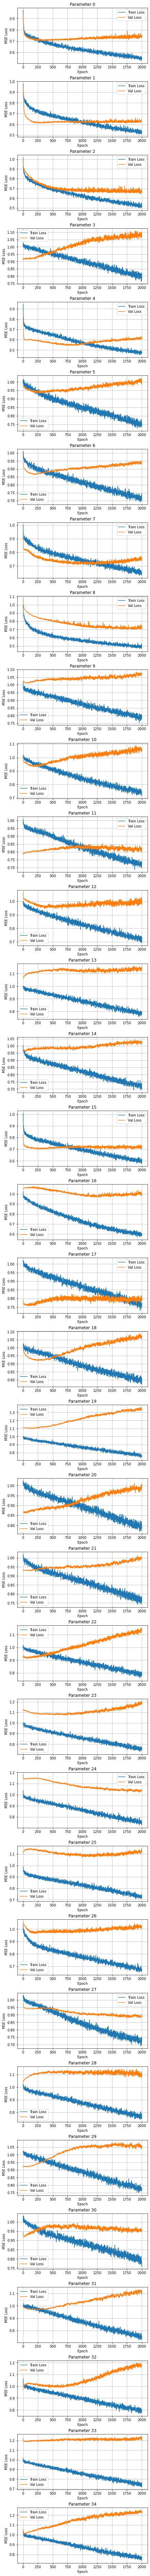

In [13]:
n_params = y.shape[1]
epochs = range(1, len(train_loss_list[0]) + 1)

fig, axs = plt.subplots(n_params, 1, figsize=(6, 3 * n_params), constrained_layout=True)

if n_params == 1:
    axs = [axs]  # handle single subplot case

for i in range(n_params):
    ax = axs[i]
    ax.plot(epochs, train_loss_list[i], label="Train Loss")
    ax.plot(epochs, val_loss_list[i], label="Val Loss")
    ax.set_title(f"Parameter {i}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(True)


#plt.savefig("../../Ms_Mh_s90.png")
plt.show()


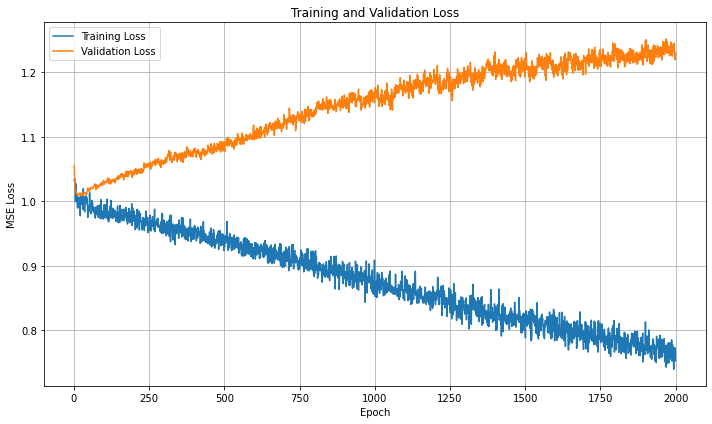

In [14]:
plt.figure(figsize=(10, 6))
epochs_range = range(1, 2000 + 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig("../../training_plot_unnormalized.png")
plt.show()

In [15]:
predictions_by_observable = []
true_values_by_observable = []

# Loop over each observable
for obs_idx, model_list in enumerate(models_by_observable):
    preds_per_param = []
    trues_per_param = []

    # Loop over each parameter for this observable
    for param_idx, model in enumerate(model_list):
        val_loader = all_val_loaders[obs_idx][param_idx]

        model.eval()
        preds_batches = []
        trues_batches = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)

                preds_batches.append(preds.cpu())
                trues_batches.append(yb.cpu())

        # Concatenate batches
        preds = torch.cat(preds_batches).numpy().flatten()
        trues = torch.cat(trues_batches).numpy().flatten()

        # Denormalize
        preds = preds * stds[param_idx] + means[param_idx]
        trues = trues * stds[param_idx] + means[param_idx]

        # Exponentiate if log flag
        if isinstance(logflag, (list, np.ndarray)):
            if logflag[param_idx]:
                preds = np.exp(preds)
                trues = np.exp(trues)
        else:
            if logflag:
                preds = np.exp(preds)
                trues = np.exp(trues)

        preds_per_param.append(preds)
        trues_per_param.append(trues)

    predictions_by_observable.append(preds_per_param)
    true_values_by_observable.append(trues_per_param)


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


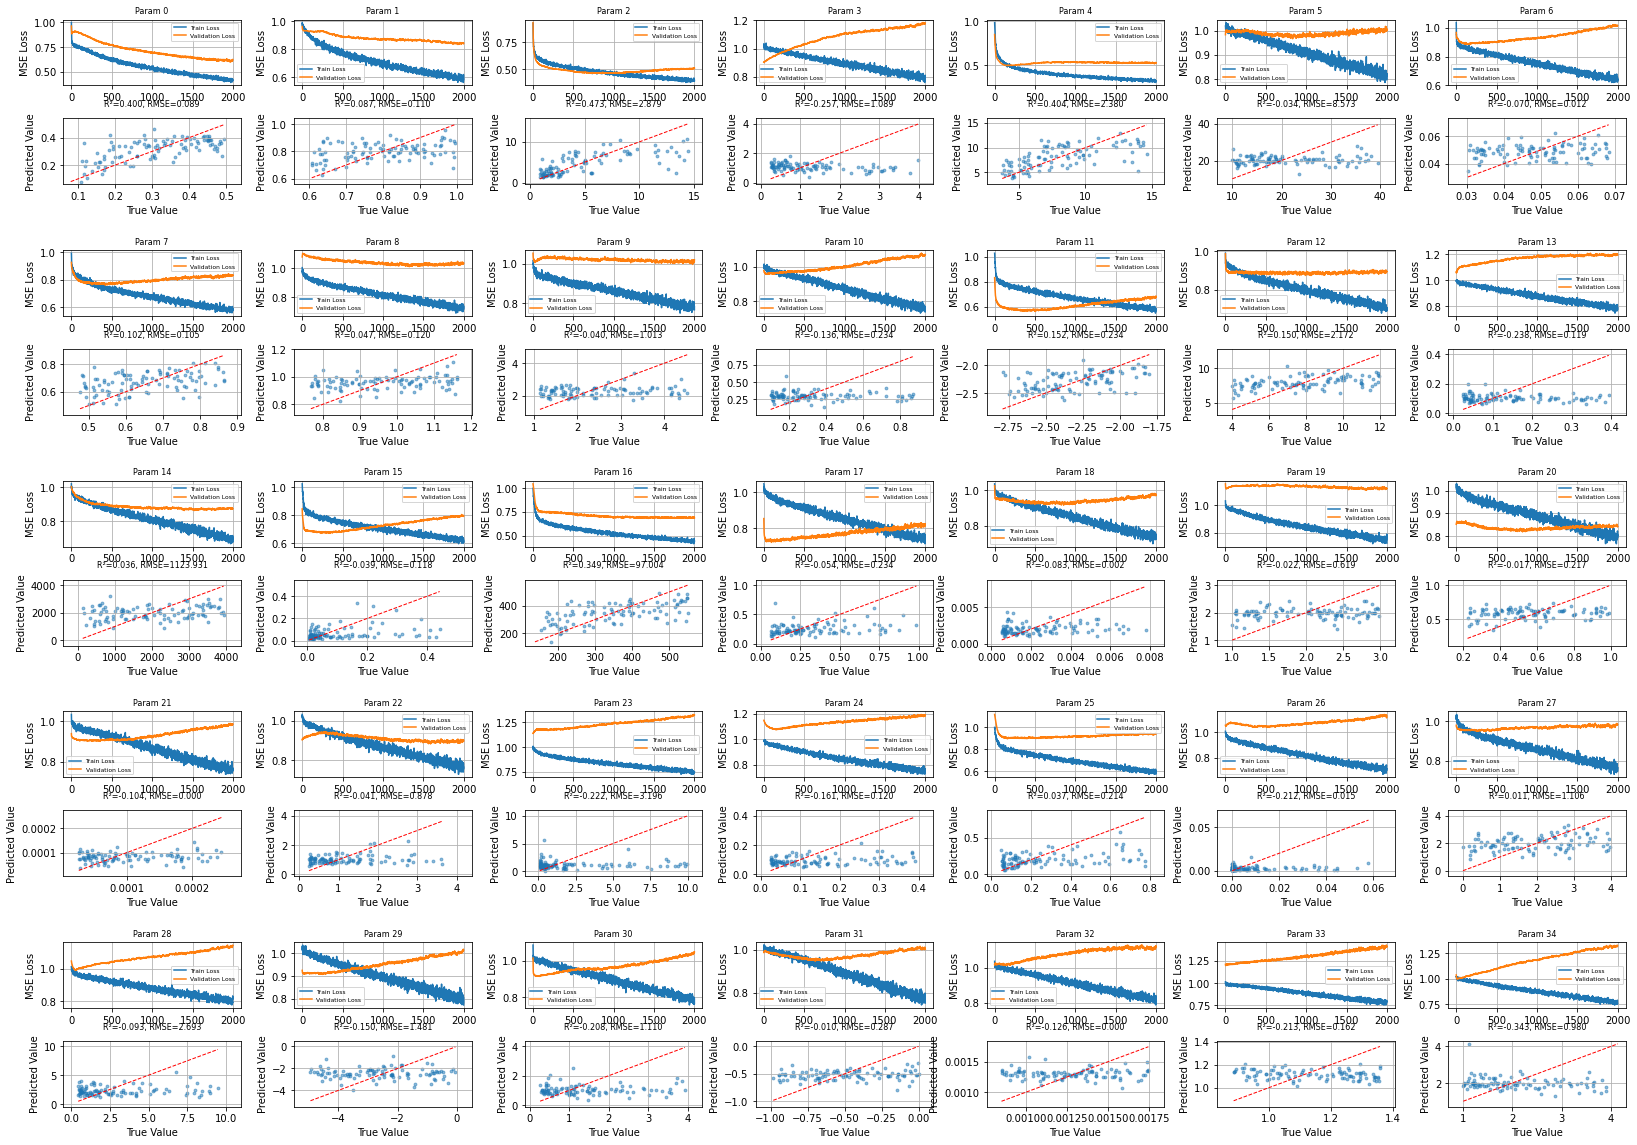

Saved figure for observable 0 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_0_grid_panels.png


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


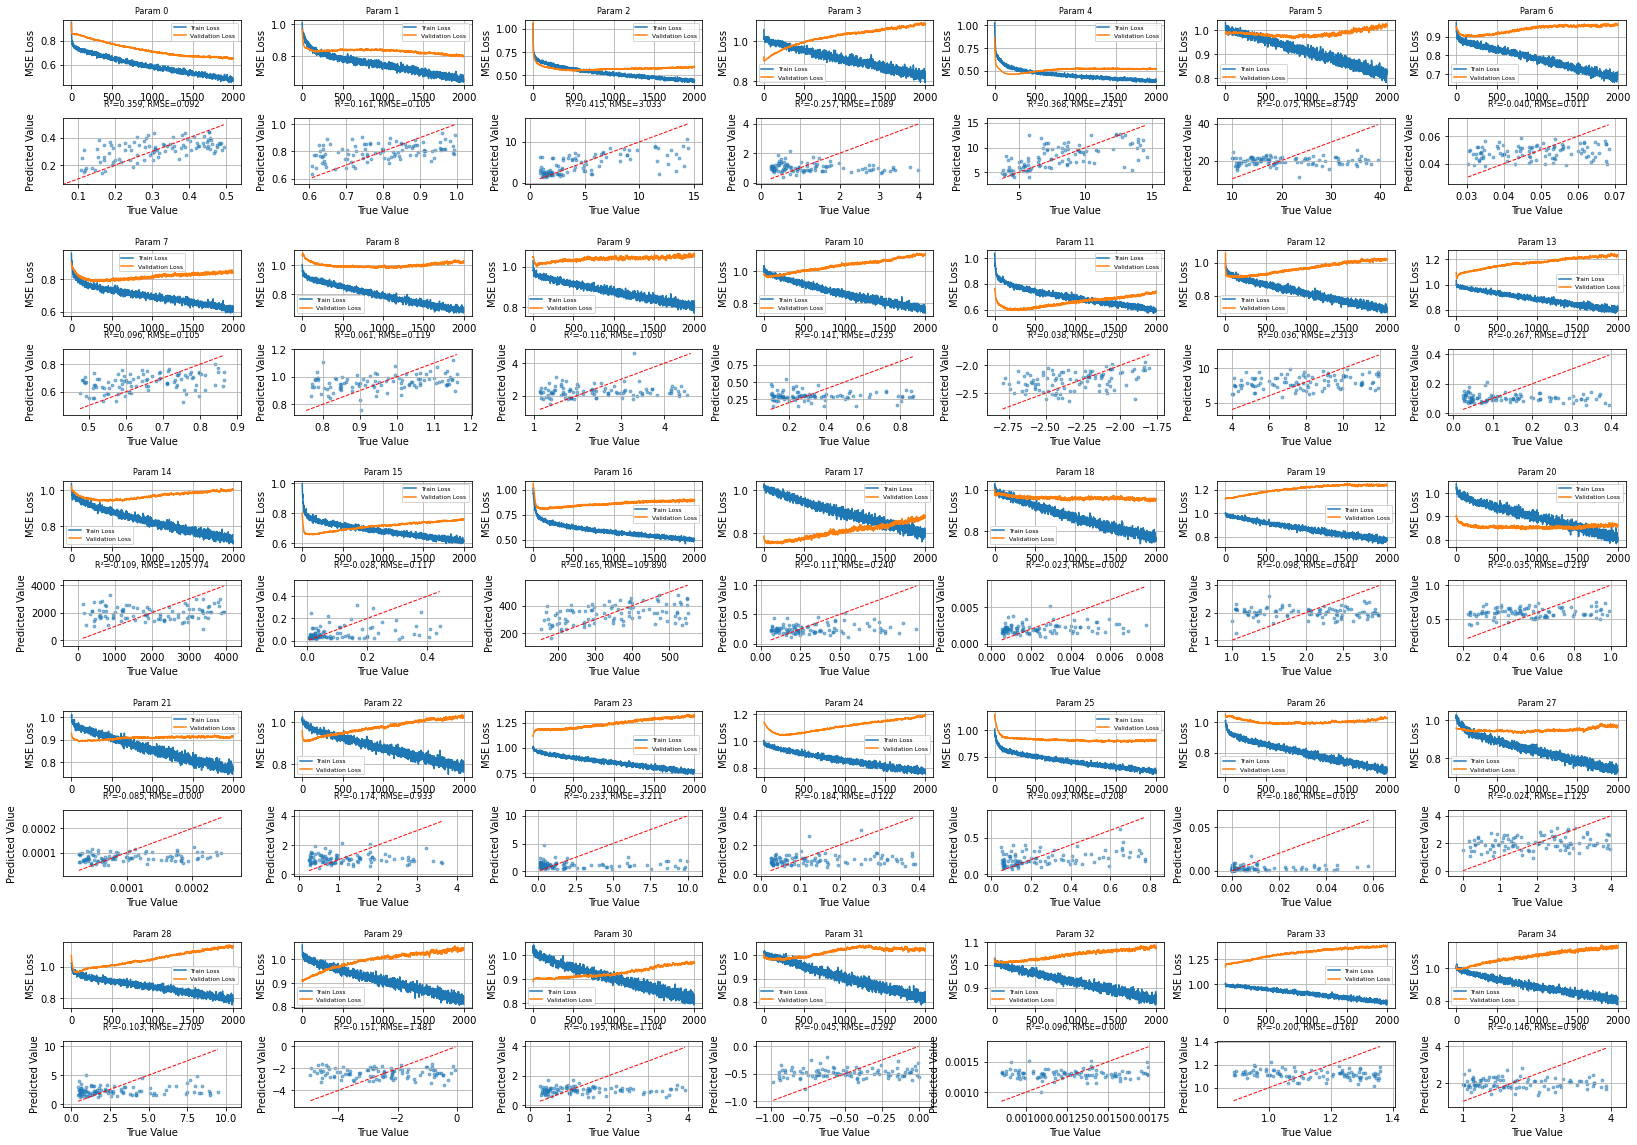

Saved figure for observable 1 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_1_grid_panels.png


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


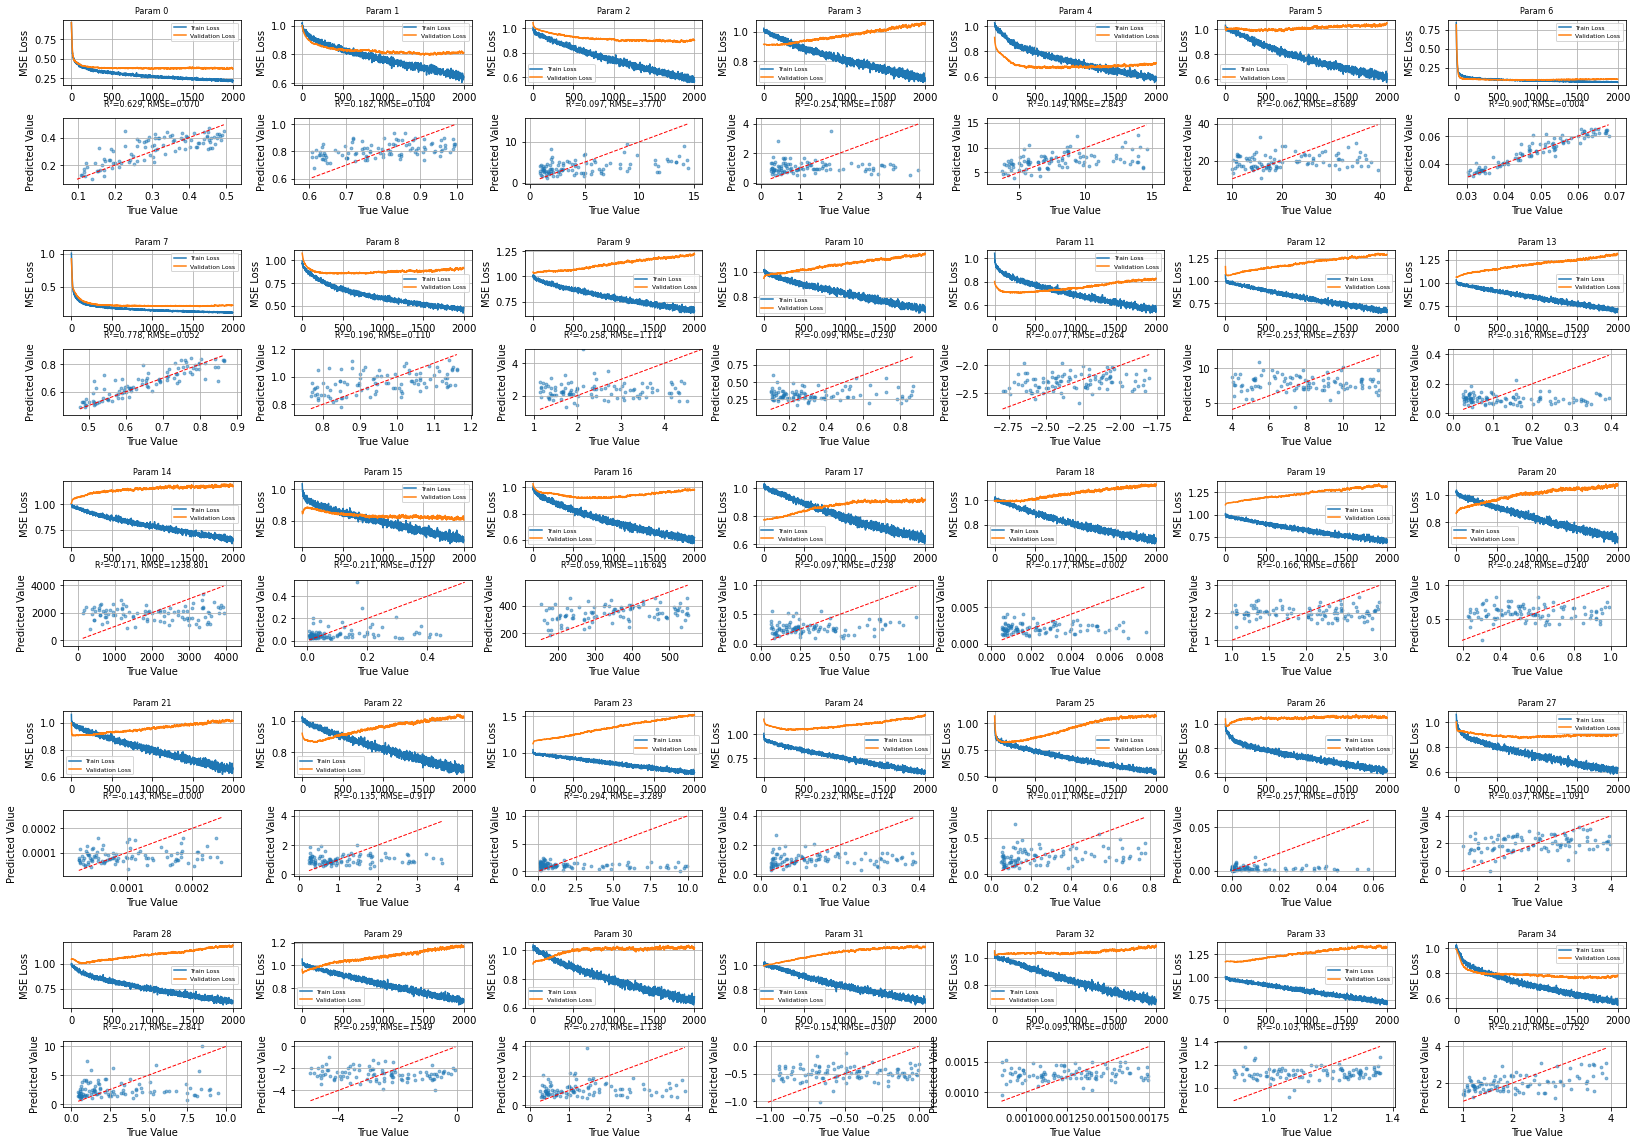

Saved figure for observable 2 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_2_grid_panels.png


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


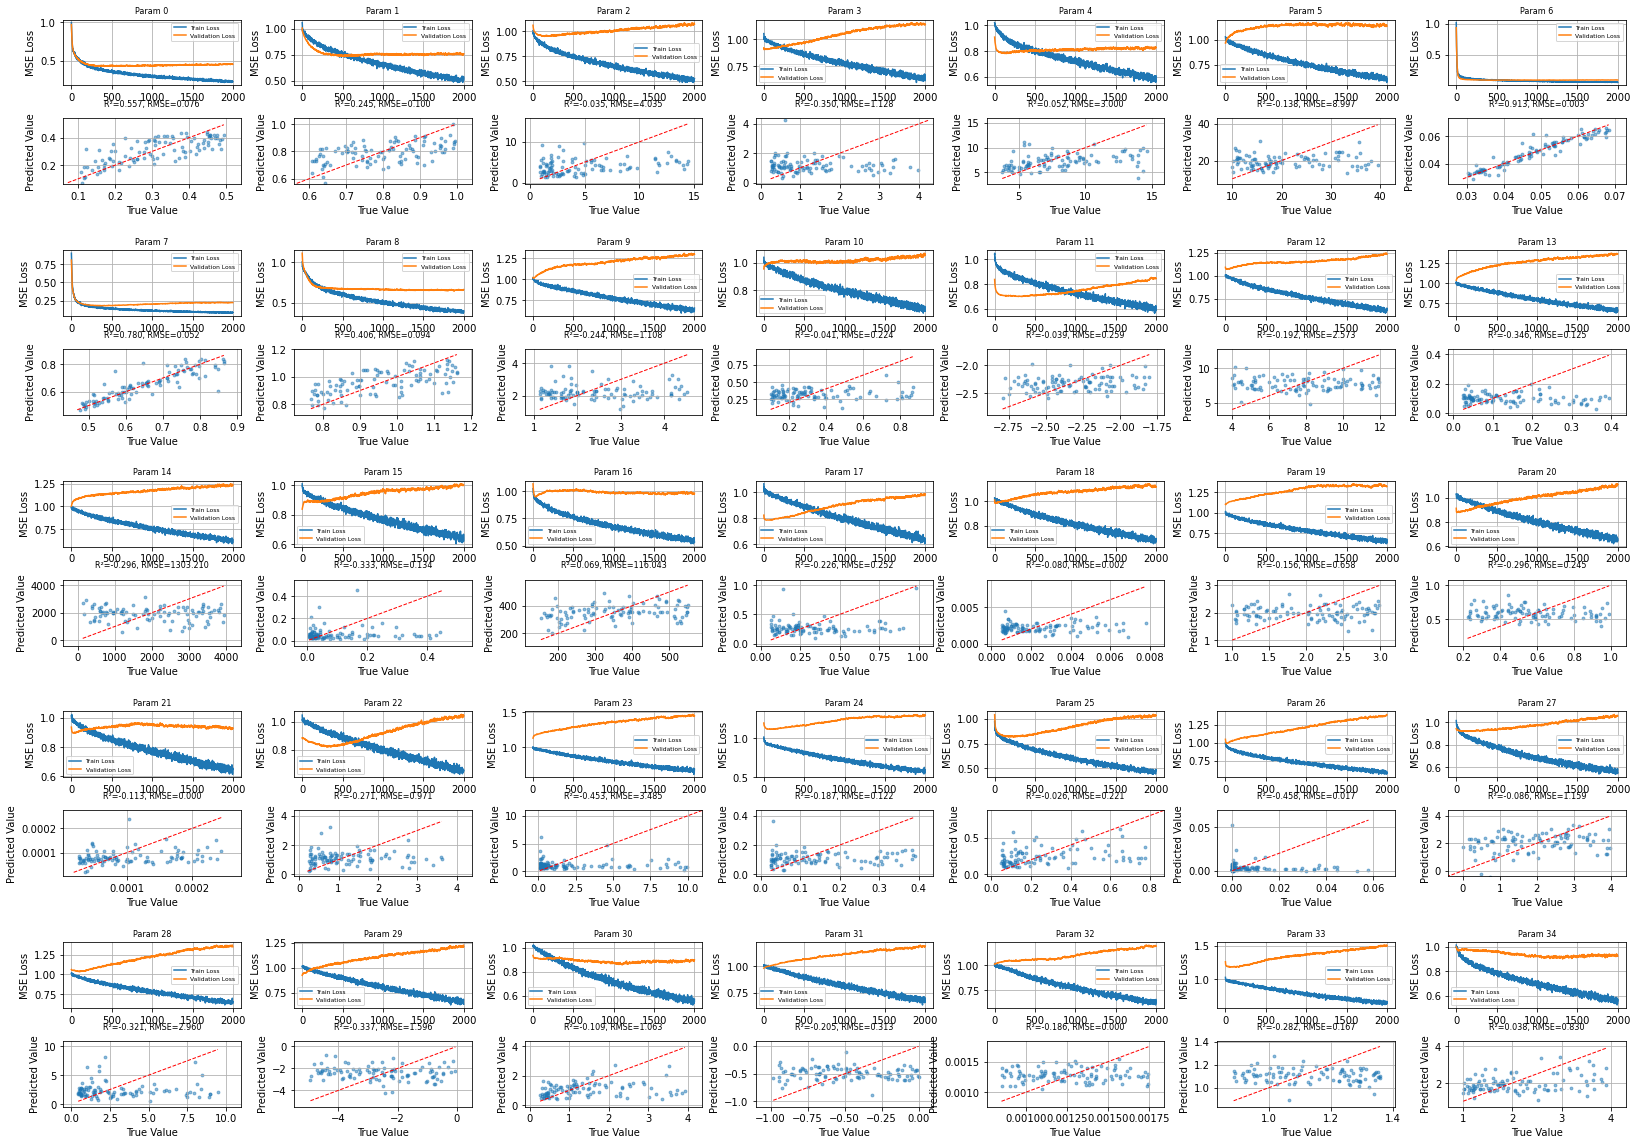

Saved figure for observable 3 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_3_grid_panels.png


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


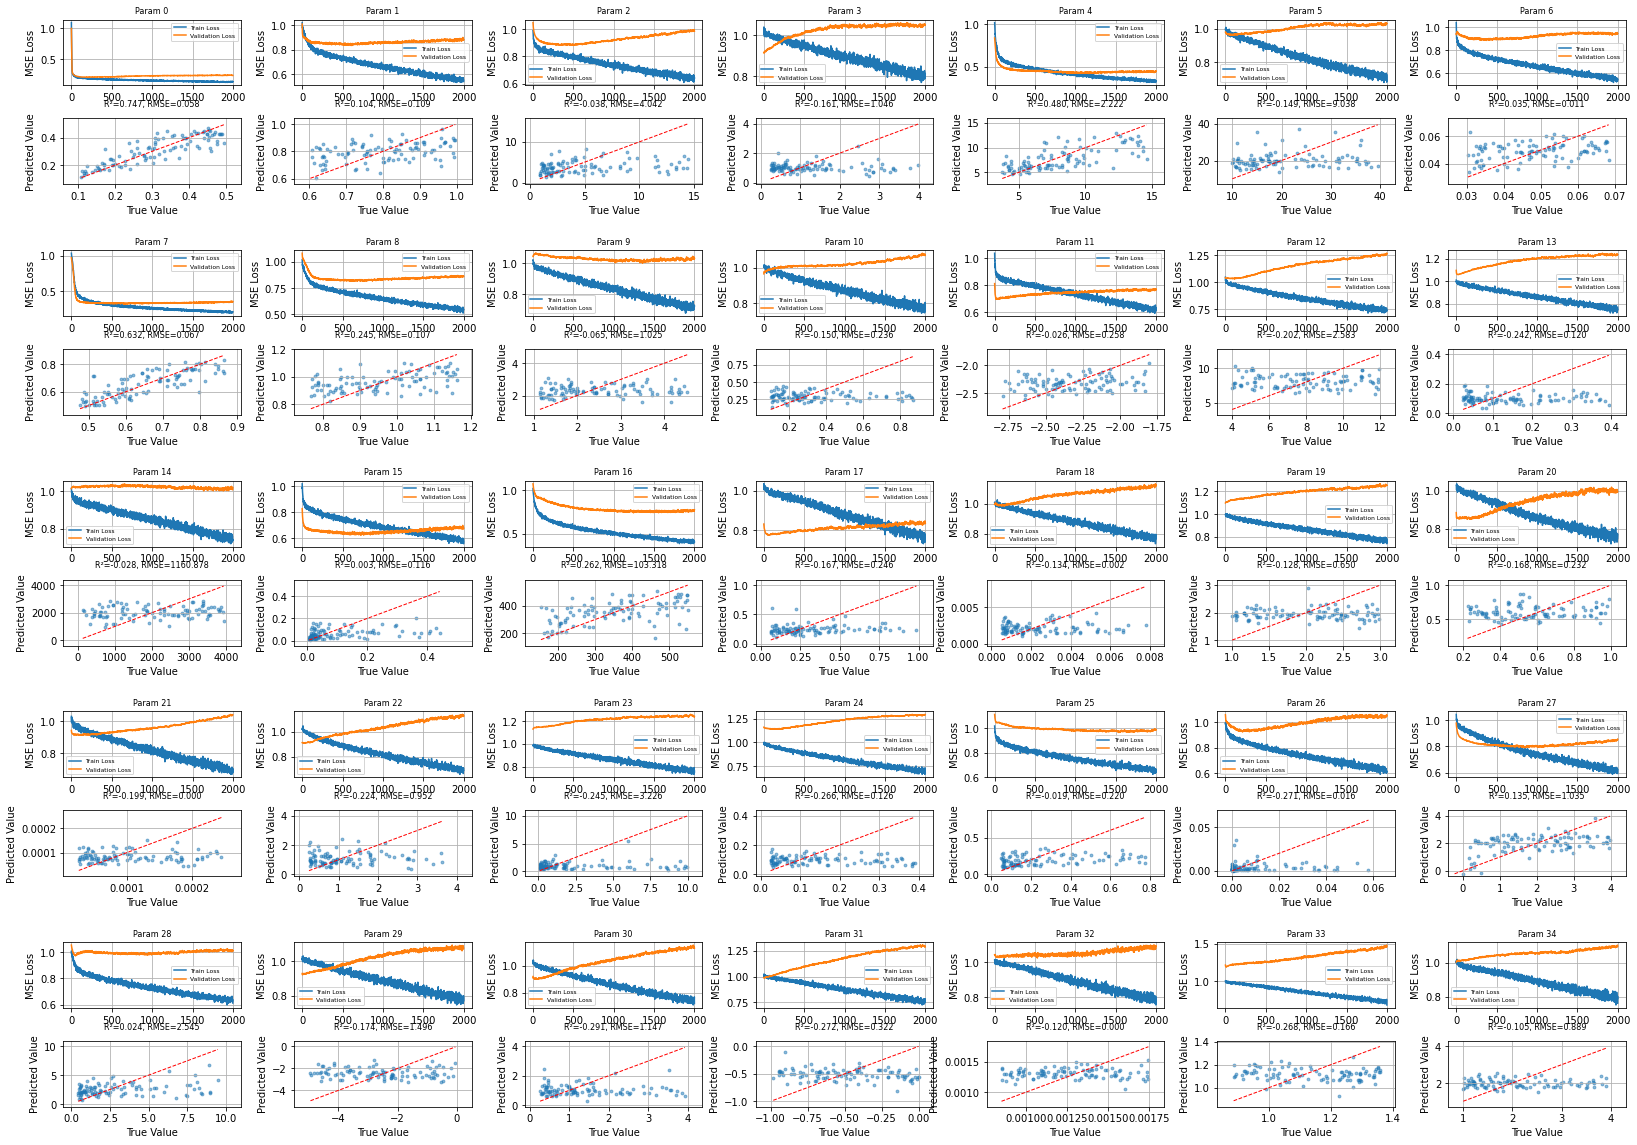

Saved figure for observable 4 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_4_grid_panels.png


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


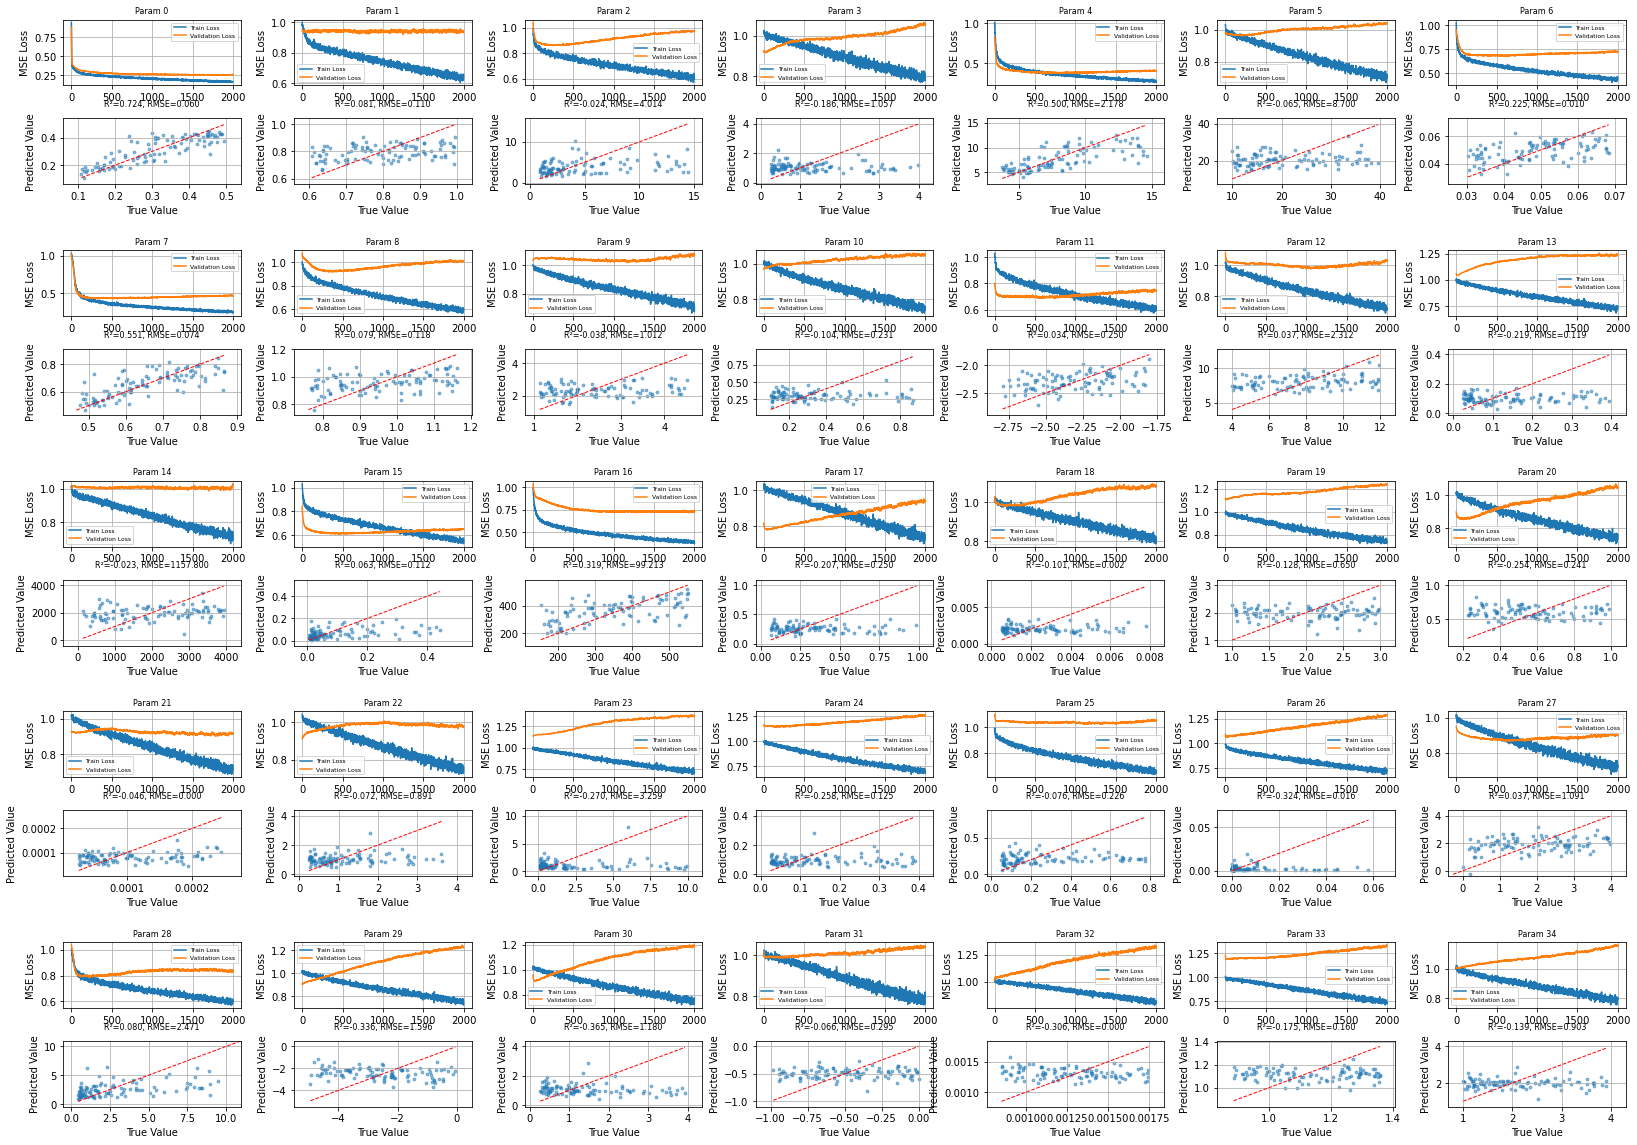

Saved figure for observable 5 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_5_grid_panels.png


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


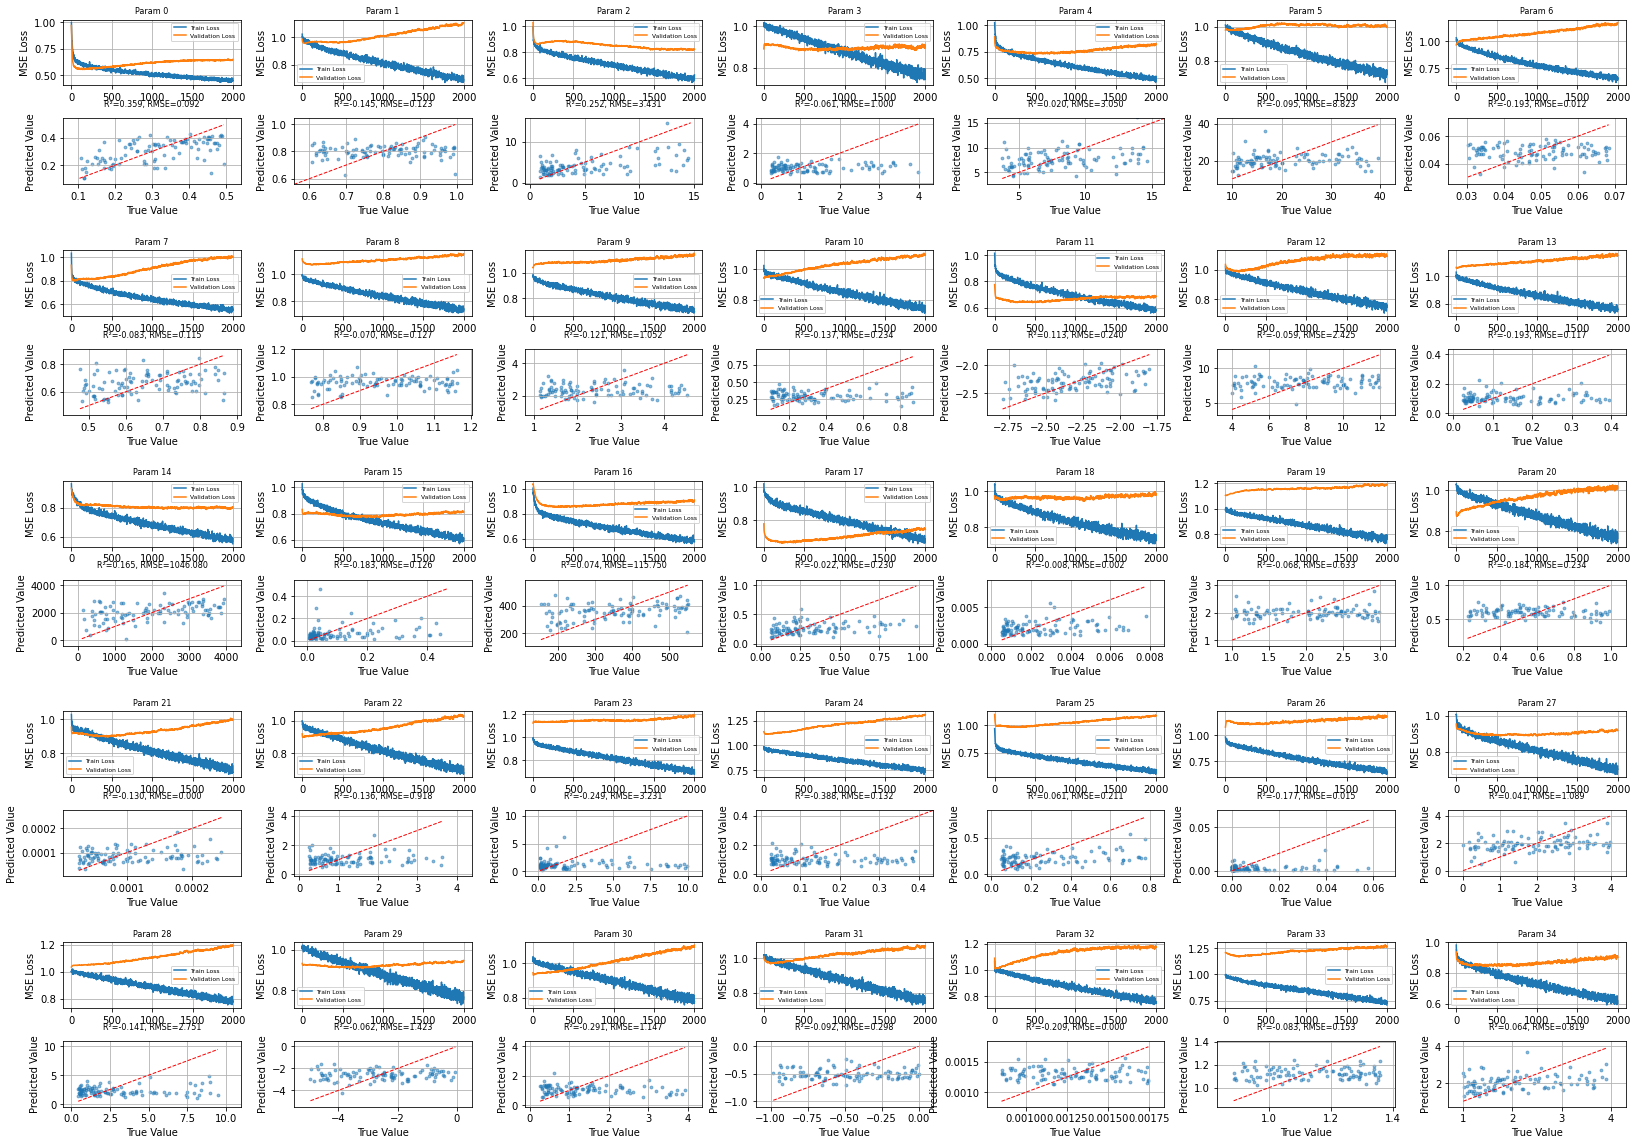

Saved figure for observable 6 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_6_grid_panels.png


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


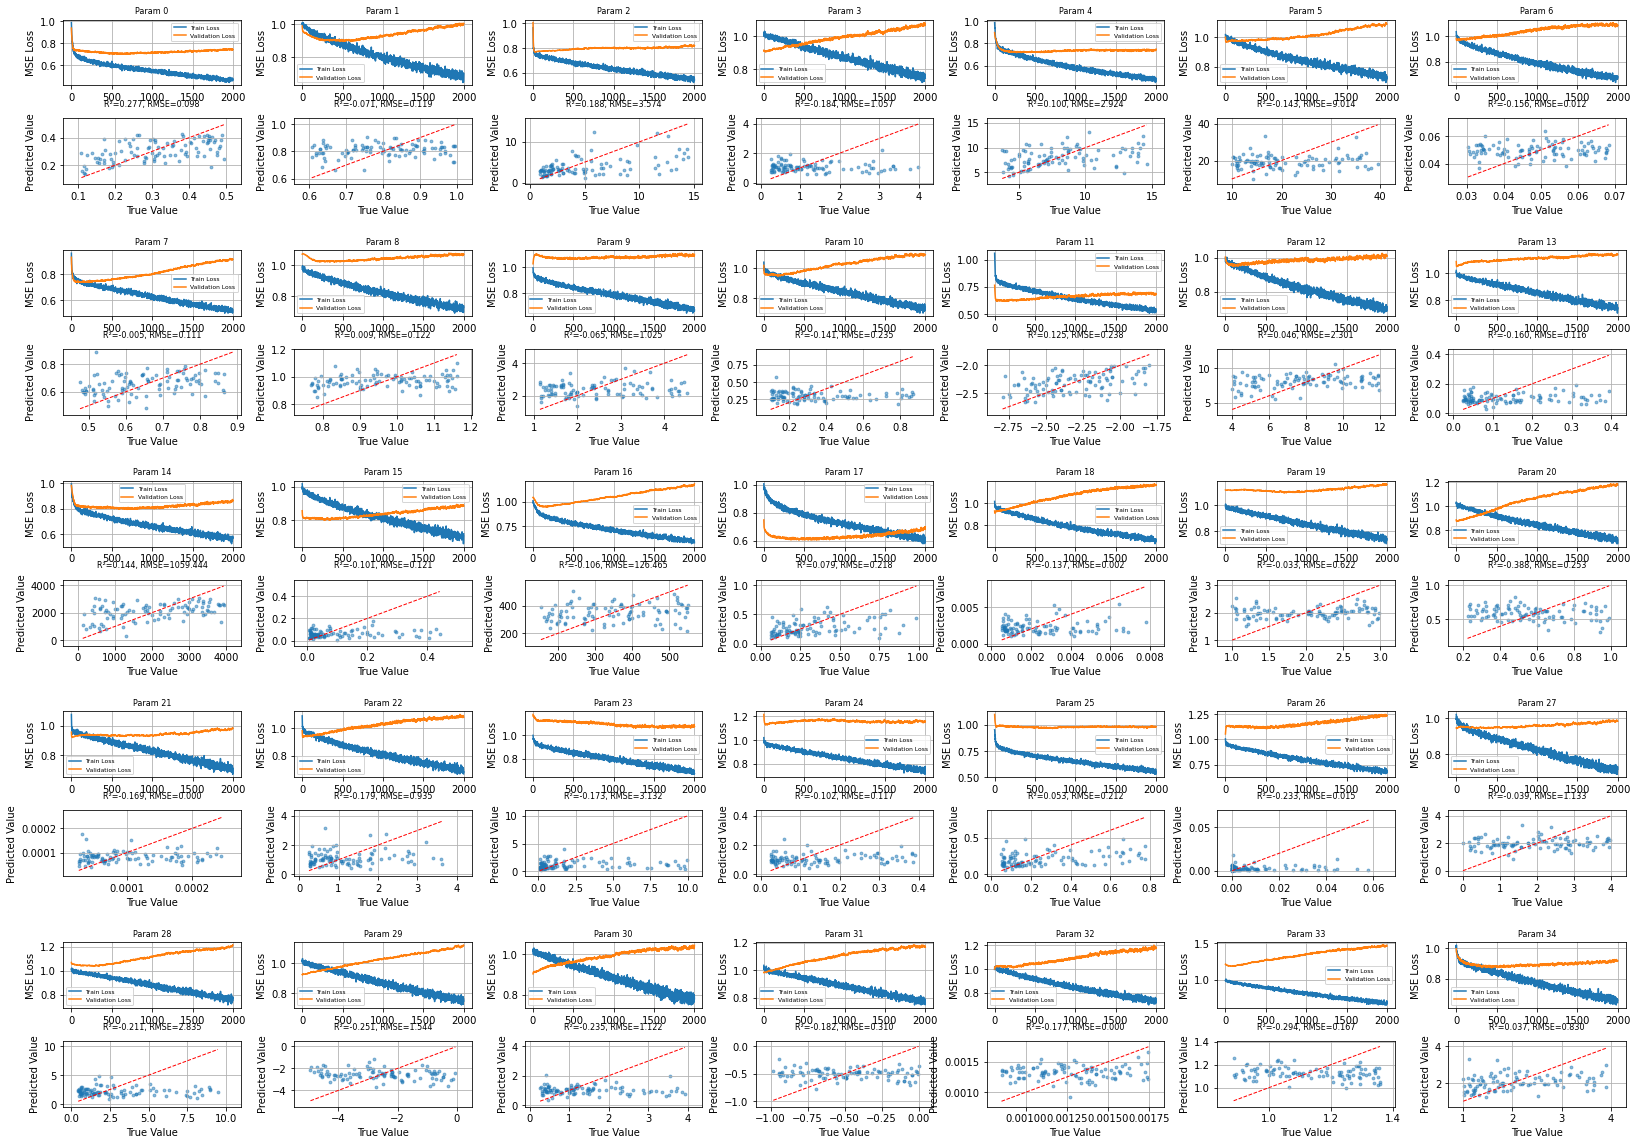

Saved figure for observable 7 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_7_grid_panels.png


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


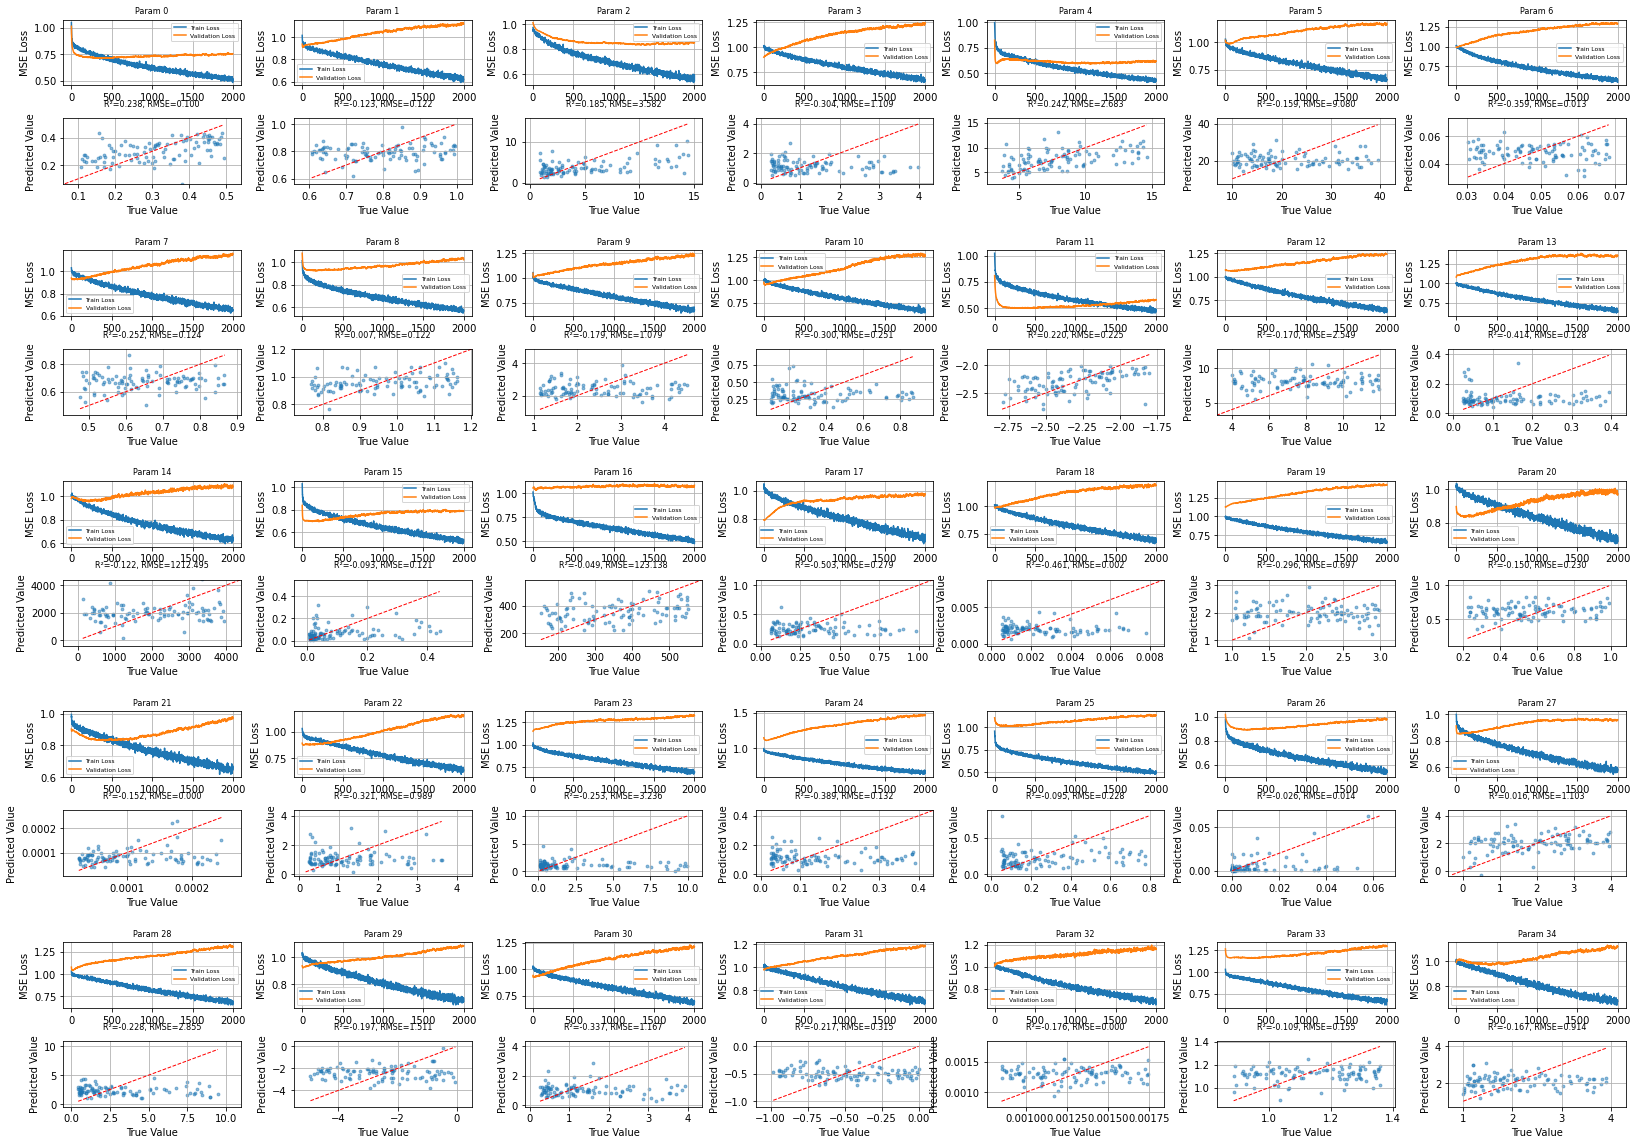

Saved figure for observable 8 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_8_grid_panels.png


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


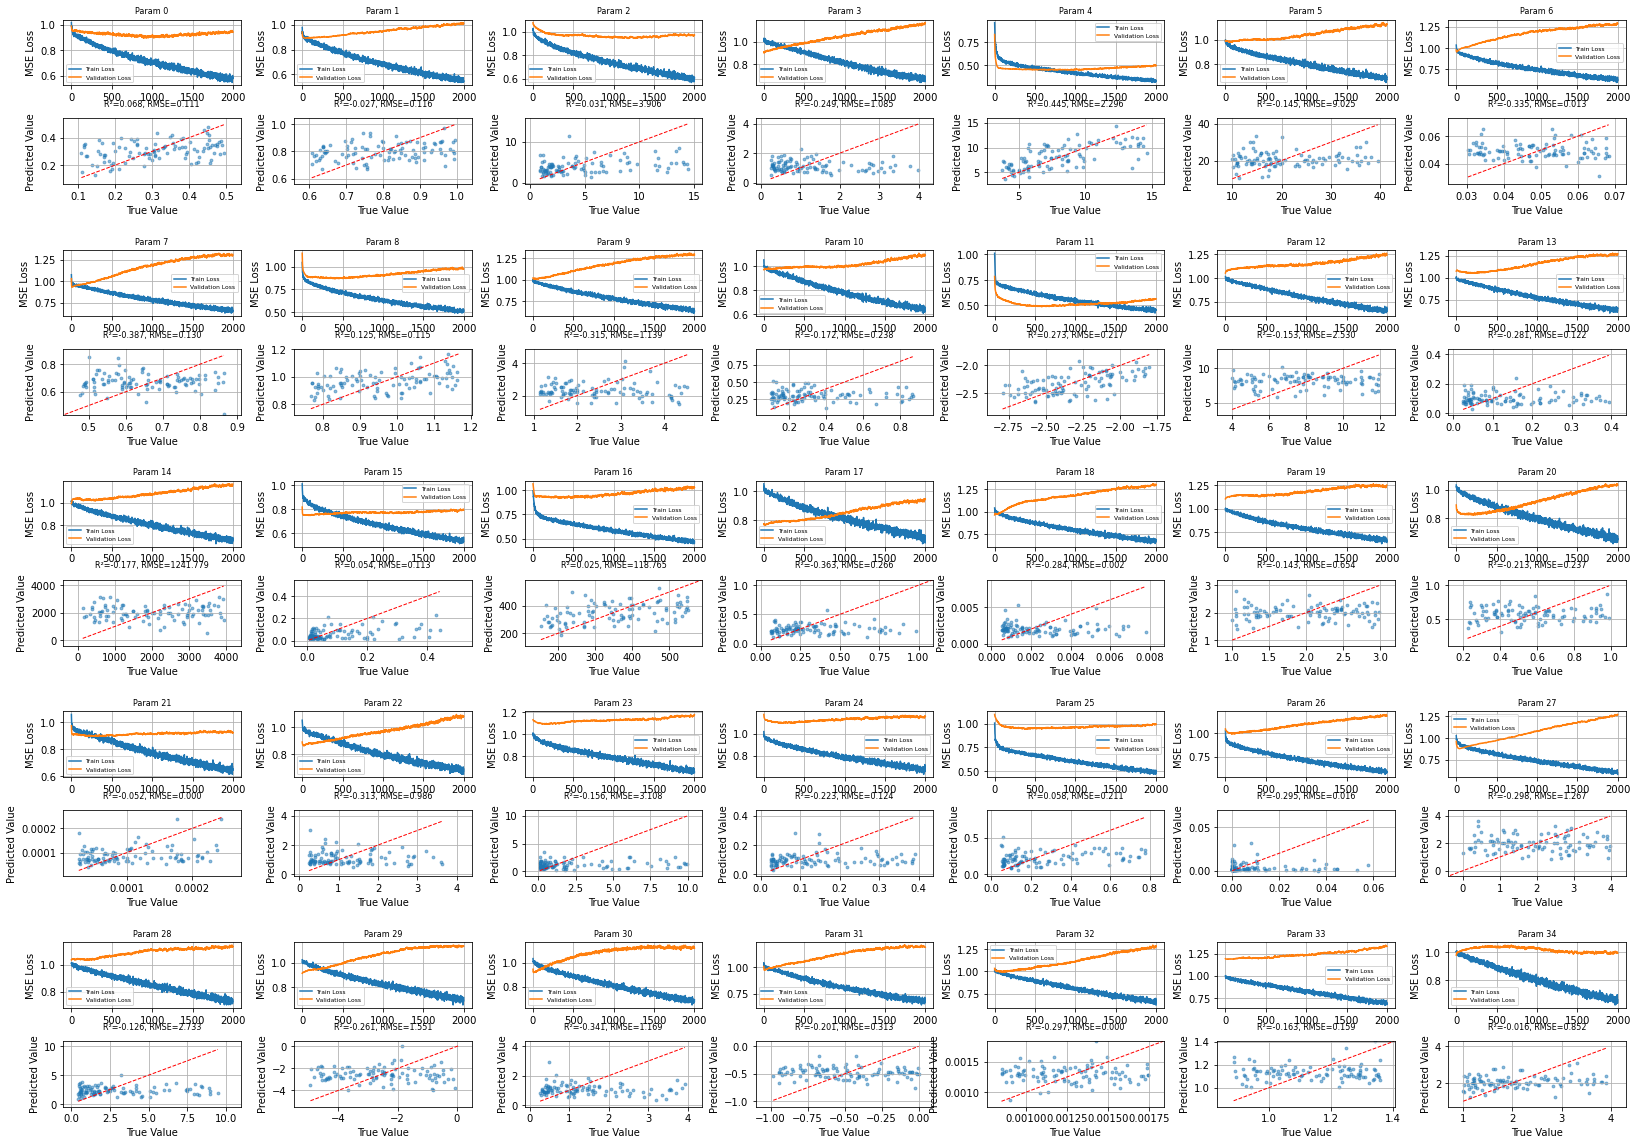

Saved figure for observable 9 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_9_grid_panels.png


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


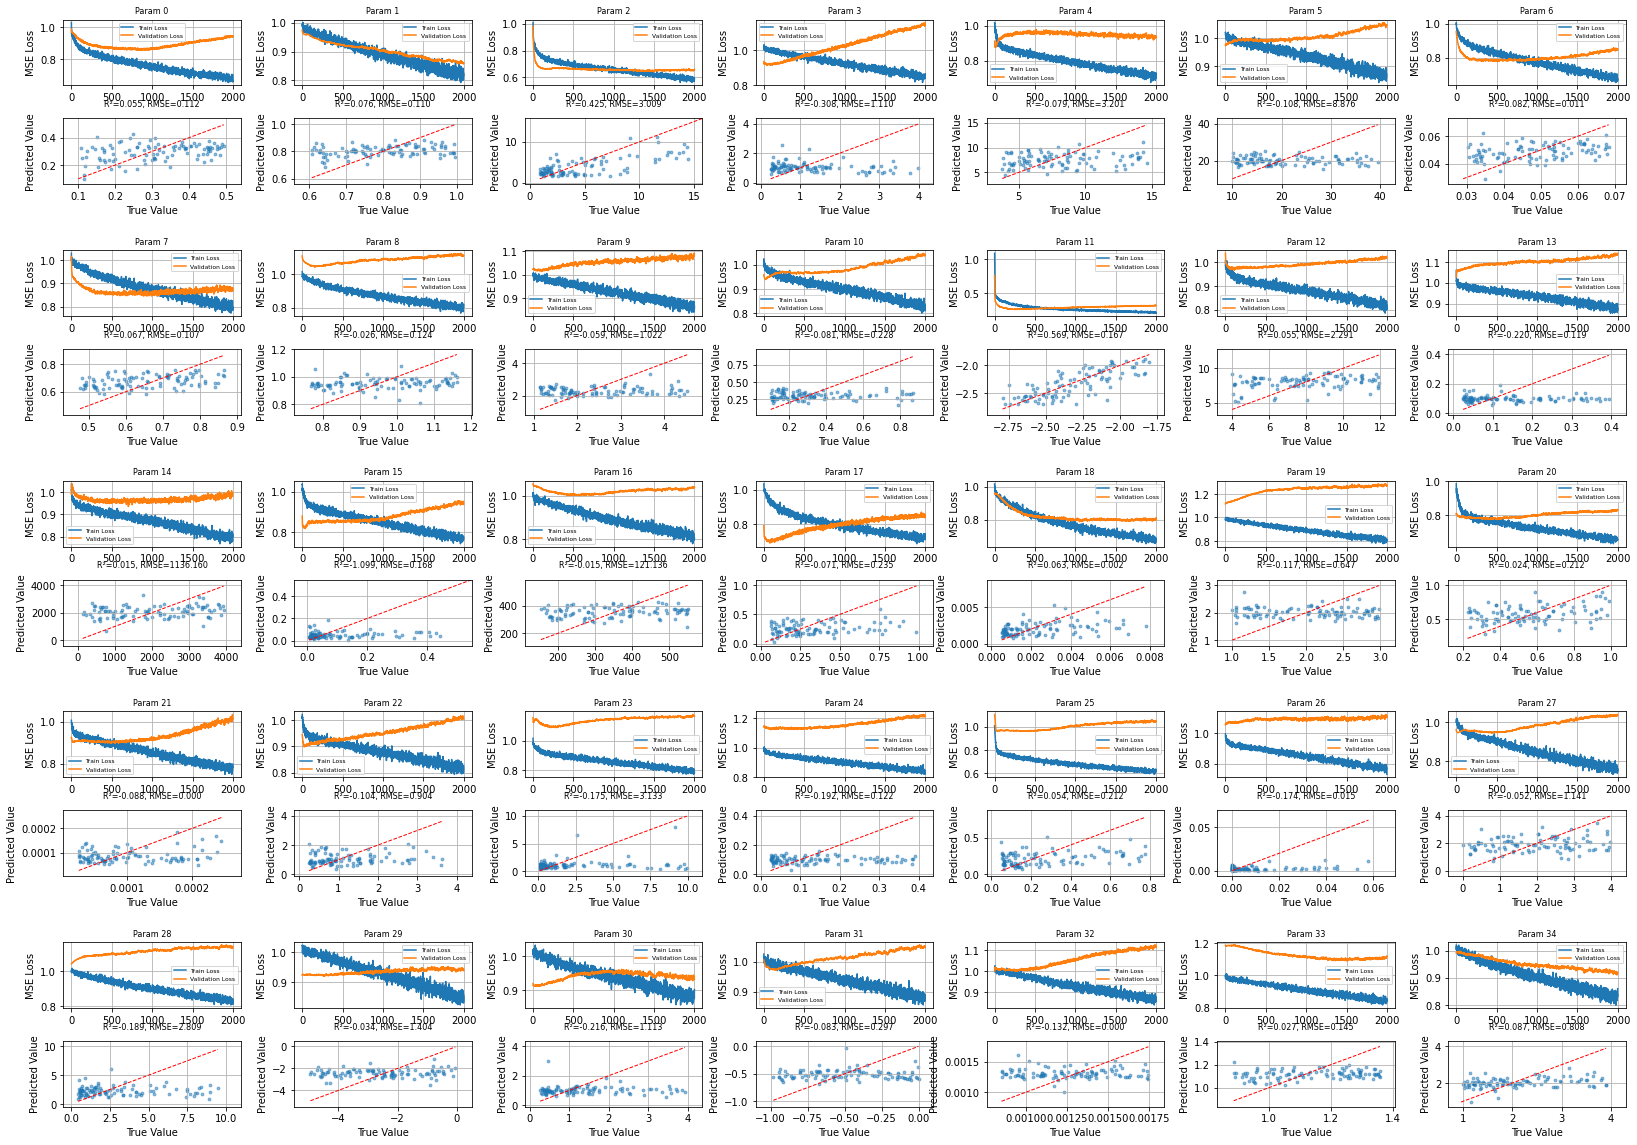

Saved figure for observable 10 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_10_grid_panels.png


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


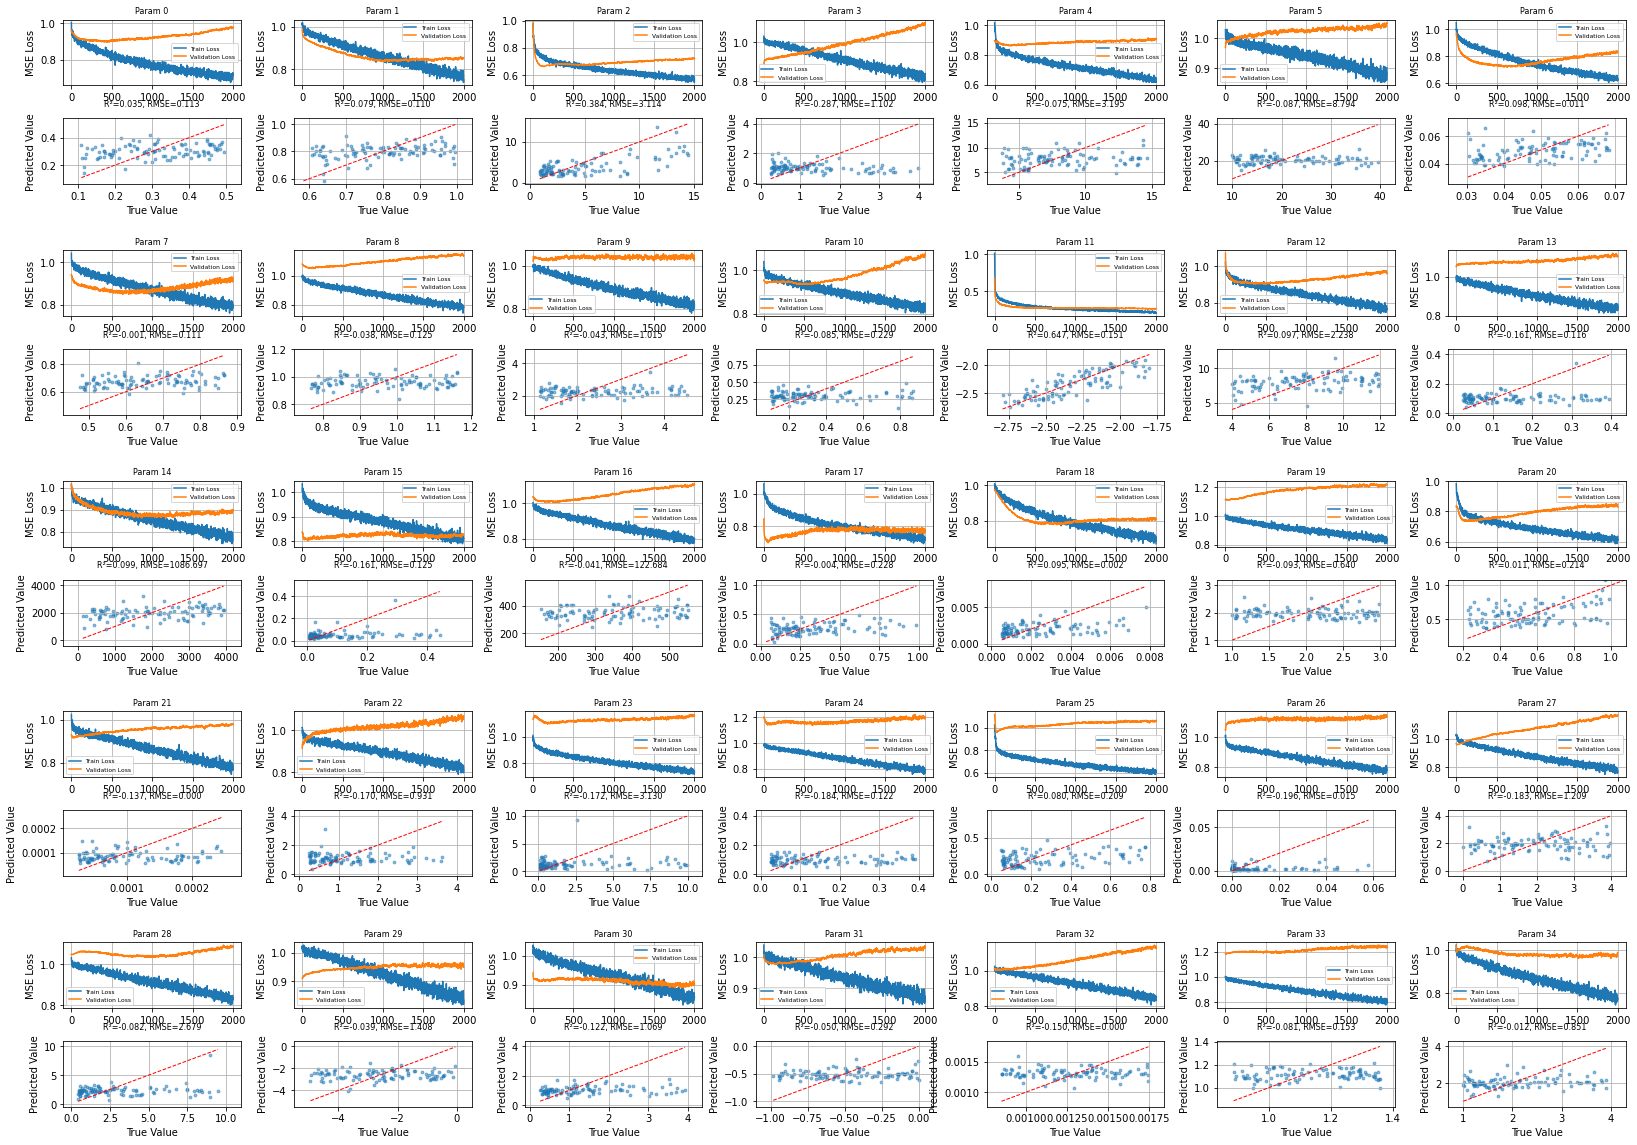

Saved figure for observable 11 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_11_grid_panels.png


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_96511/2442618452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


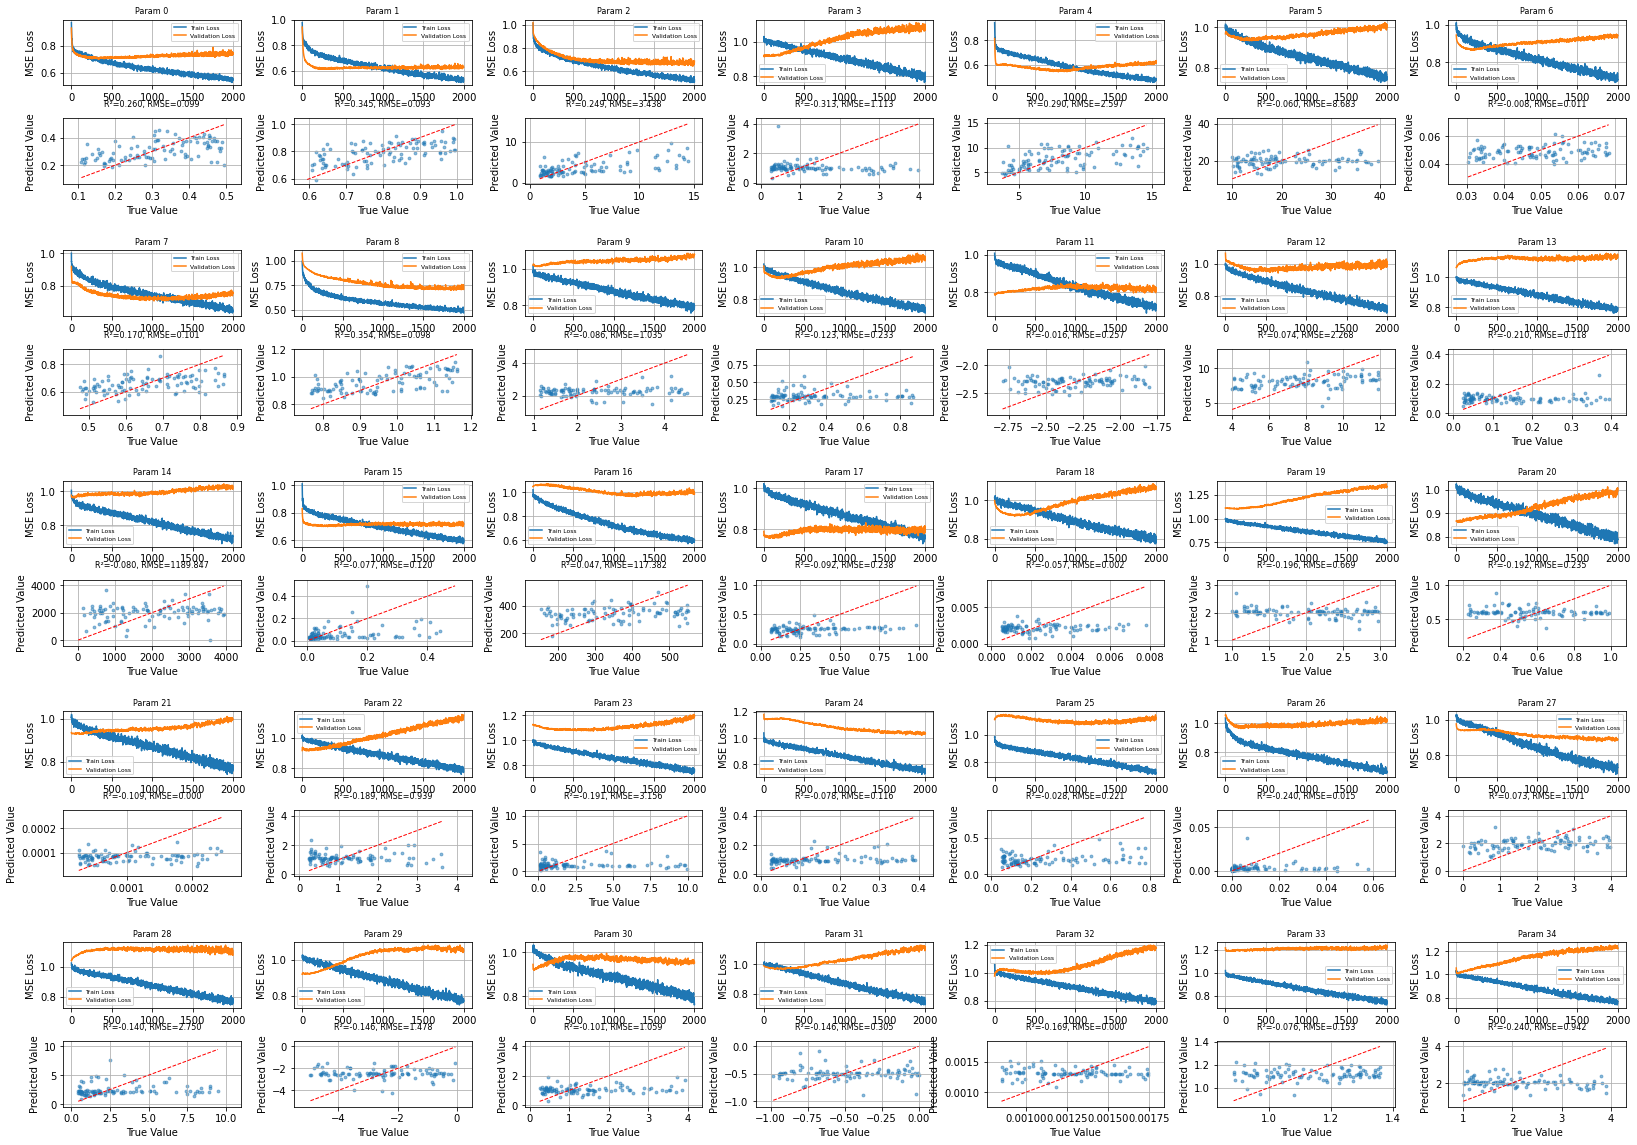

Saved figure for observable 12 to:
/Users/nicolasgarcia/Downloads/GAL_SBI/grid_results/results_observable_12_grid_panels.png


In [16]:
import os 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np


r2_array = np.zeros((len(val_losses_by_observable), len(val_losses_by_observable[0])))
rmse_array = np.zeros((len(val_losses_by_observable), len(val_losses_by_observable[0])))

output_dir = os.path.abspath(os.path.join(os.getcwd(), "../../grid_results"))
os.makedirs(output_dir, exist_ok=True)

# Loop over all observables
for obs_idx in range(len(predictions_by_observable)):
    Nrows, Ncols = 5, 7

    # Create figure and master gridspec
    fig = plt.figure(figsize=(28, 20))
    outer_gs = gridspec.GridSpec(
        nrows=Nrows,
        ncols=Ncols,
        hspace=0.4,
        wspace=0.3
    )

    # Loop over 5×7 grid
    for i in range(Nrows):
        for j in range(Ncols):
            param_idx = i * Ncols + j

            # --- Sub-GridSpec for this parameter ---
            inner_gs = gridspec.GridSpecFromSubplotSpec(
                nrows=2,
                ncols=1,
                subplot_spec=outer_gs[i, j],
                height_ratios=[1, 1],
                hspace=0.5  # More vertical space
            )

            # --- Top: Loss ---
            ax_loss = fig.add_subplot(inner_gs[0])

            train_loss = train_losses_by_observable[obs_idx][param_idx]
            val_loss = val_losses_by_observable[obs_idx][param_idx]

            ax_loss.plot(train_loss, label="Train Loss")
            ax_loss.plot(val_loss, label="Validation Loss")
            ax_loss.set_title(f"Param {param_idx}", fontsize=8)
            ax_loss.set_xlabel("")  # Remove x-label on top plot
            ax_loss.set_ylabel("MSE Loss")
            ax_loss.legend(fontsize=6)
            ax_loss.grid(True)

            # --- Bottom: Scatter ---
            ax_scatter = fig.add_subplot(inner_gs[1])

            preds = predictions_by_observable[obs_idx][param_idx]
            trues = true_values_by_observable[obs_idx][param_idx]

            r2 = r2_score(trues, preds)
            rmse = np.sqrt(mean_squared_error(trues, preds))
            
            #save the r2 and rmse values to use for heatmap and other statistic summaries
            r2_array[obs_idx, param_idx] = r2
            rmse_array[obs_idx, param_idx] = rmse


            ax_scatter.scatter(trues, preds, alpha=0.5, s=8)

            min_val = min(trues.min(), preds.min())
            max_val = max(trues.max(), preds.max())
            ax_scatter.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

            ax_scatter.set_xlabel("True Value")
            ax_scatter.set_ylabel("Predicted Value")
            ax_scatter.set_title(f"R²={r2:.3f}, RMSE={rmse:.3f}", fontsize=8, pad=12)  # Added pad
            ax_scatter.grid(True)

            # Consistent scaling
            param_min = origParameters.min(axis=0)[param_idx]
            param_max = origParameters.max(axis=0)[param_idx]
            pad = (param_max - param_min) * 0.1

            ax_scatter.set_xlim(param_min - pad, param_max + pad)
            ax_scatter.set_ylim(param_min - pad, param_max + pad)

    # Save and show
    plt.tight_layout()
    save_path = os.path.join(output_dir, f"results_observable_{obs_idx}_grid_panels.png")
    plt.savefig(save_path, dpi=200)
    plt.show()

    print(f"Saved figure for observable {obs_idx} to:\n{save_path}")


In [35]:
rmse_matrix = np.zeros((len(val_losses_by_observable), len(val_losses_by_observable[0])))
r2_matrix = np.zeros((len(val_losses_by_observable), len(val_losses_by_observable[0])))

for obs_idx in range(len(val_losses_by_observable)):
    for param_idx in range(len(val_losses_by_observable[obs_idx])):
        val_loss_history = val_losses_by_observable[obs_idx][param_idx]
        trues = true_values_by_observable[obs_idx][param_idx]
        
        mse = min(val_loss_history)
        variance = np.var(trues)  # defaults to ddof=0 (population variance)
        
        rmse_matrix[obs_idx, param_idx] = mse  # store MSE for now
        r2_matrix[obs_idx, param_idx] = 1 - (mse / variance)

# Take square root to convert MSE → RMSE
rmse_matrix = np.sqrt(rmse_matrix)

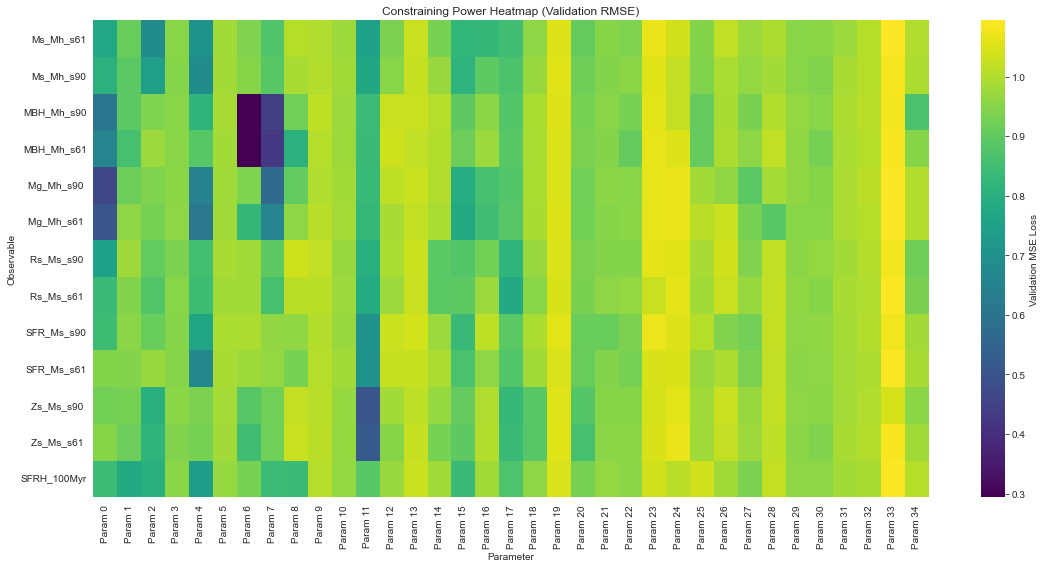

In [79]:
import seaborn as sns
import pandas as pd

# Create a DataFrame for nicer labels (optional)
rmse_df = pd.DataFrame(
    rmse_matrix,
    index=[f"{i}" for i in observable_block.keys()],
    columns=[f"Param {j}" for j in range(rmse_matrix.shape[1])]
)

plt.figure(figsize=(16, 8))
sns.heatmap(
    rmse_df,
    cmap="viridis",
    annot=False,
    fmt=".2e",
    cbar_kws={'label': 'Validation MSE Loss'}
)
sns.set_style("white")
plt.title("Constraining Power Heatmap (Validation RMSE)")
plt.ylabel("Observable")
plt.xlabel("Parameter")
plt.tight_layout()
plt.savefig("../../grid_results/heatmap_rmse_seaborn.png", dpi=200)
plt.show()


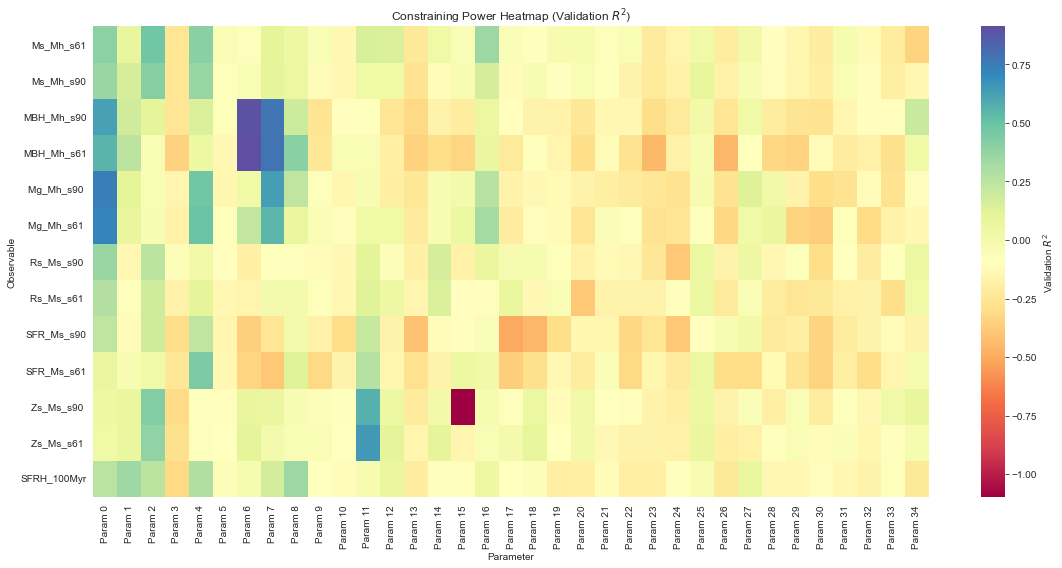

In [78]:
# Create a DataFrame for nicer labels (optional)
r2_df = pd.DataFrame(
    r2_array,
    index=[f"{i}" for i in observable_block.keys()],
    columns=[f"Param {j}" for j in range(r2_matrix.shape[1])]
)

plt.figure(figsize=(16, 8))
sns.heatmap(
    r2_df,
    cmap = 'Spectral',
    annot=False,
    fmt=".2e",
    cbar_kws={'label': 'Validation $R^{2}$'}
)
sns.set_style("white")

plt.title(f"Constraining Power Heatmap (Validation $R^{2}$)")
plt.ylabel("Observable")
plt.xlabel("Parameter")
plt.tight_layout()
#plt.savefig("../../grid_results/heatmap_rmse_seaborn.png", dpi=200)
plt.show()

In [73]:
records = []
for obs_idx in range(rmse_matrix.shape[0]):
    for param_idx in range(rmse_matrix.shape[1]):
        records.append({
            "Parameter": param_idx,
            "Observable": list(observable_block.keys())[obs_idx],
            "RMSE": rmse_matrix[obs_idx, param_idx]
        })

df_rmse = pd.DataFrame(records)

In [1]:


plt.figure(figsize=(20, 8))
sns.barplot(
    data=df_rmse,
    x="Parameter",
    y="RMSE",
    hue="Observable",
    palette="viridis"
)
plt.xlabel("Parameter Index")
plt.ylabel("Validation RMSE")
plt.title("Constraining Power per Parameter (Lower RMSE = Better)")
plt.legend(title="Observable", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
#plt.savefig("../../grid_results/constraining_rmse_bars.png", dpi=200)
plt.show()


NameError: name 'plt' is not defined

In [ ]:
len(observable_block.keys())

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

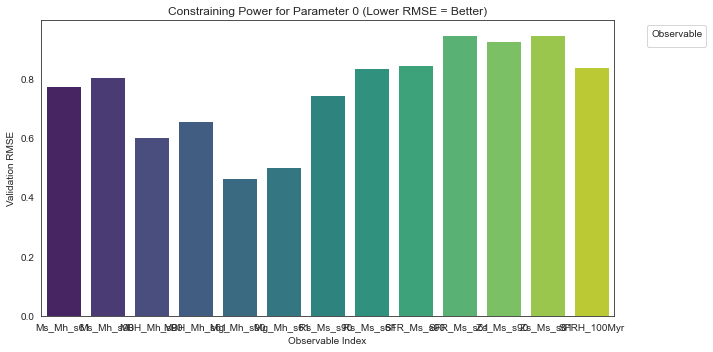

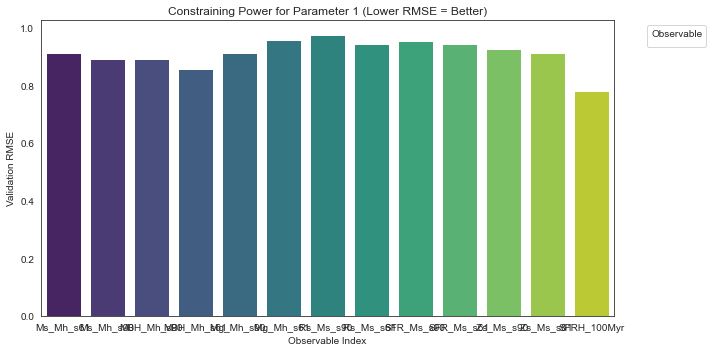

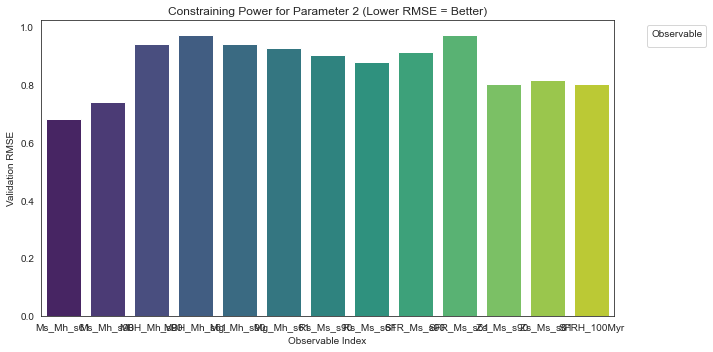

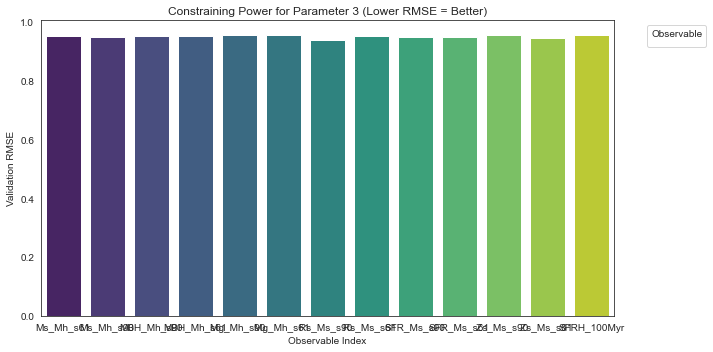

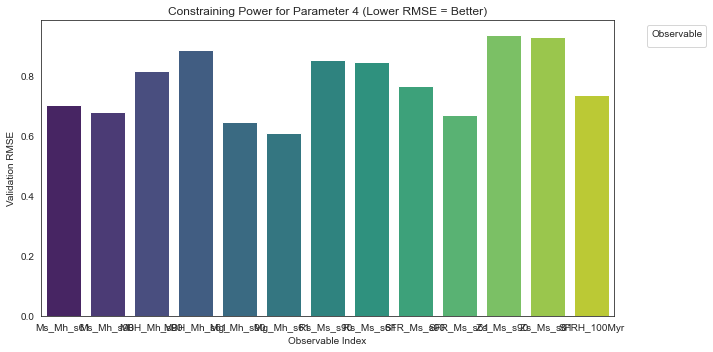

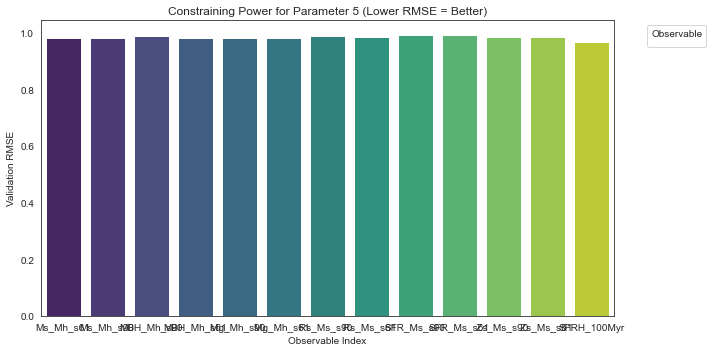

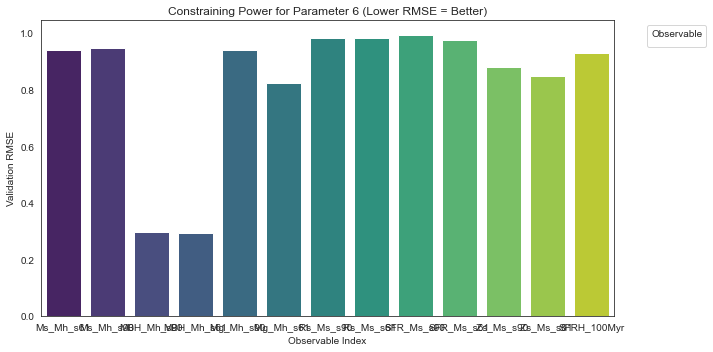

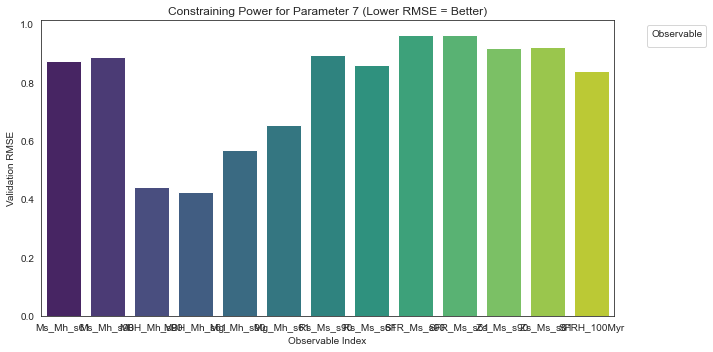

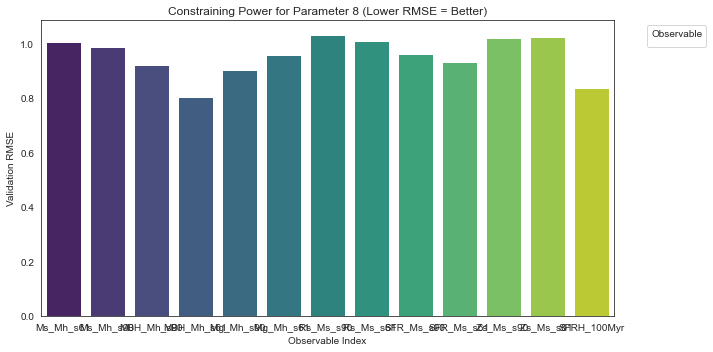

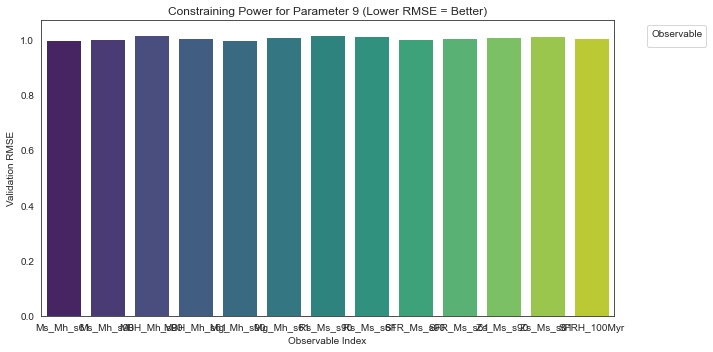

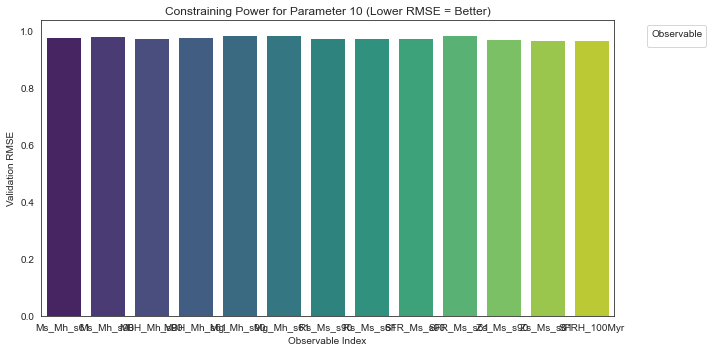

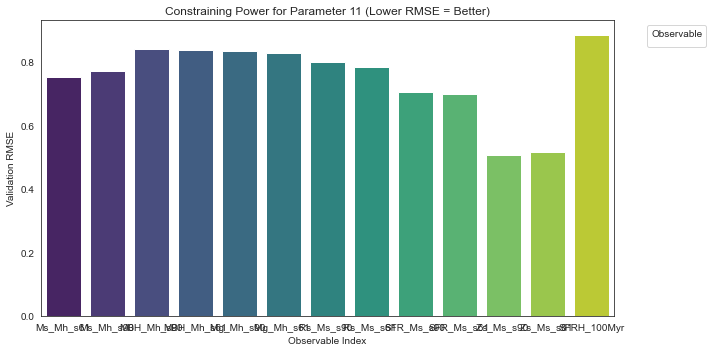

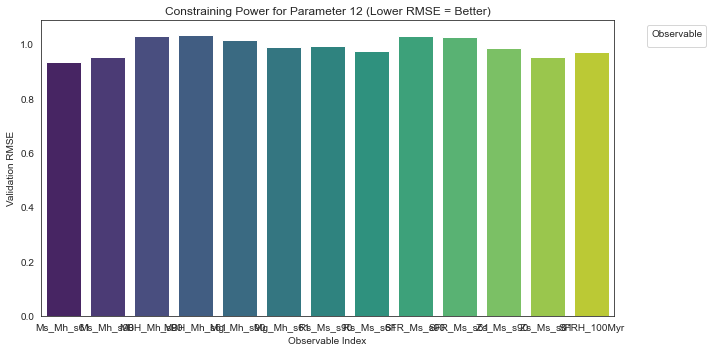

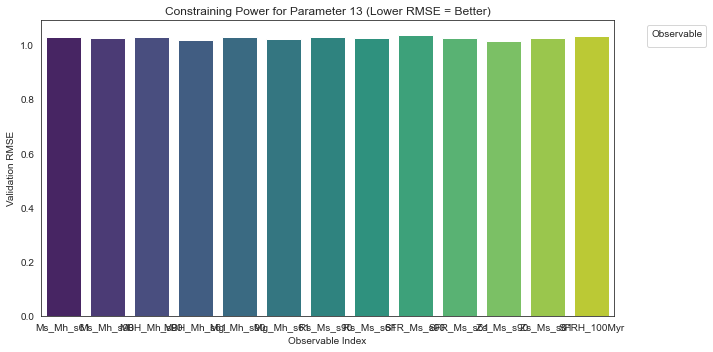

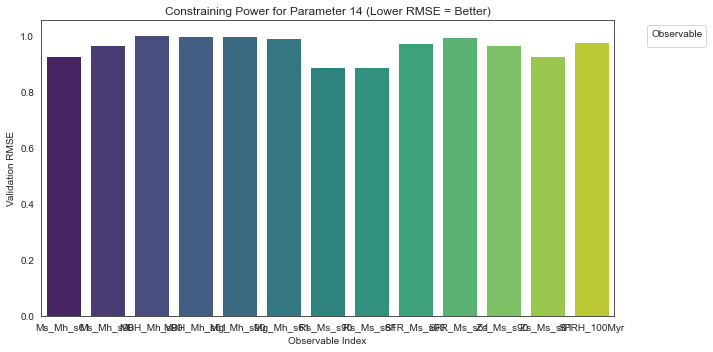

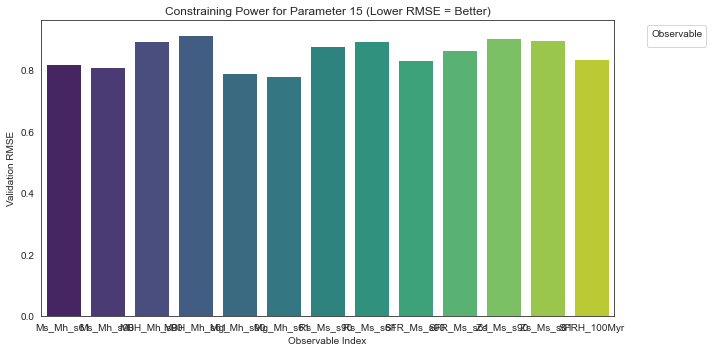

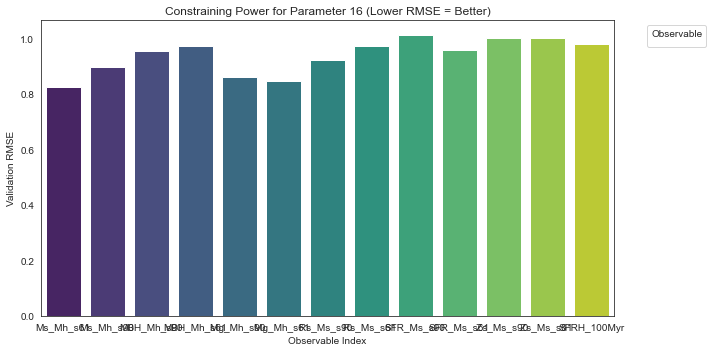

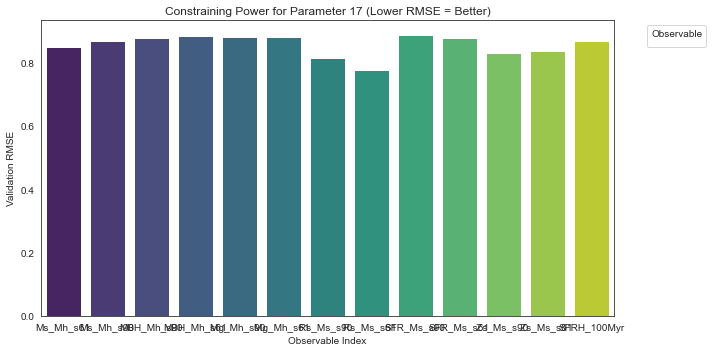

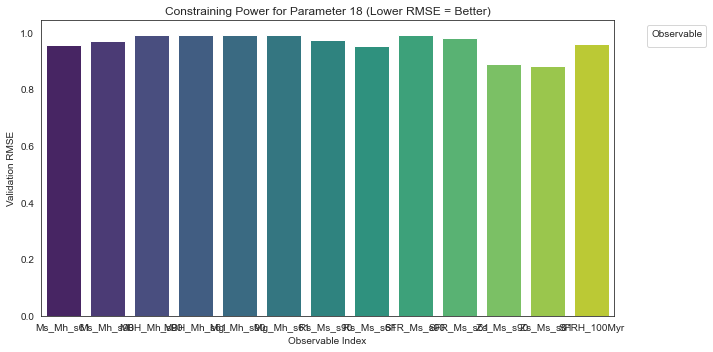

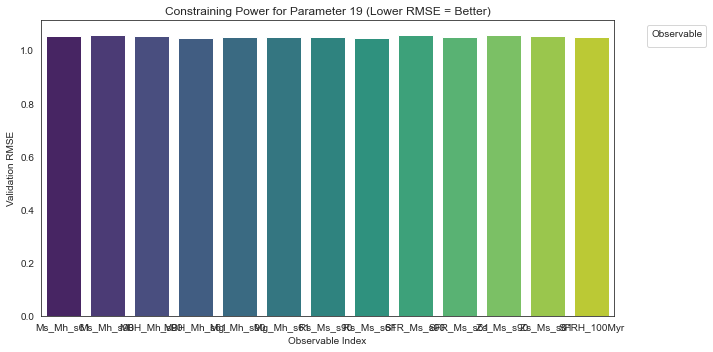

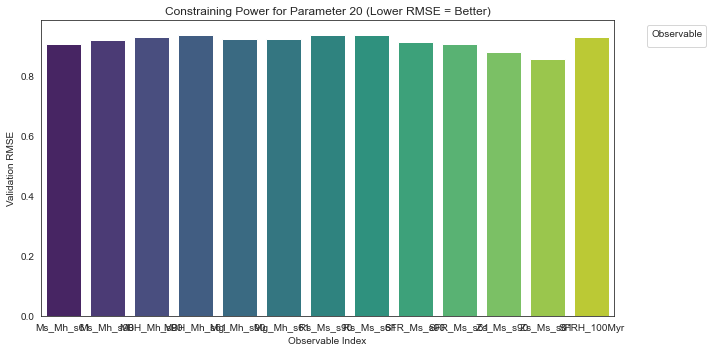

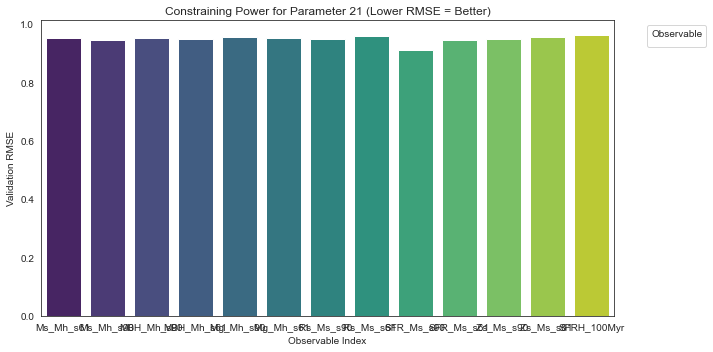

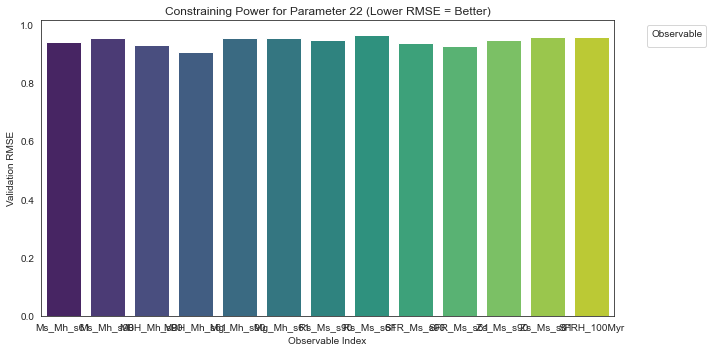

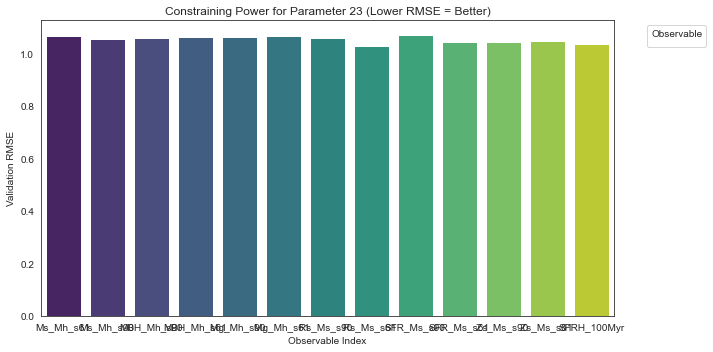

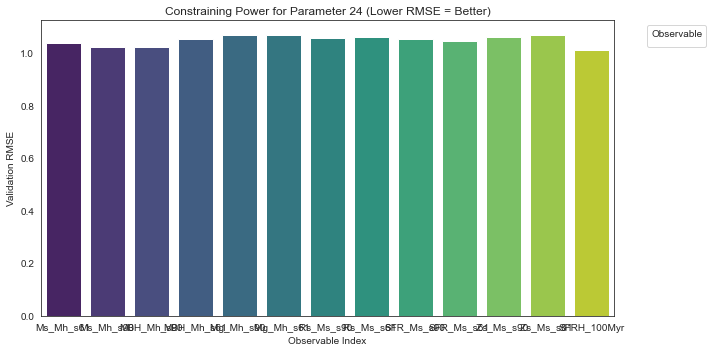

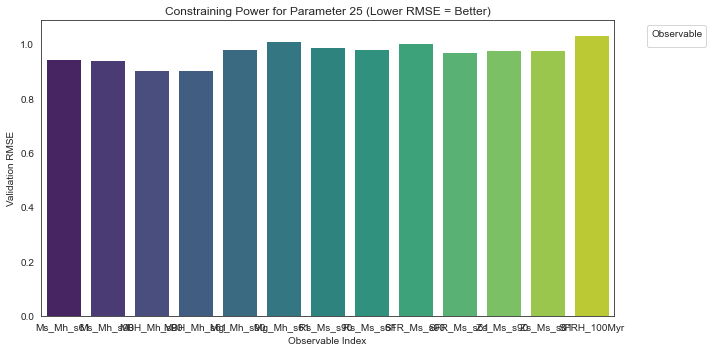

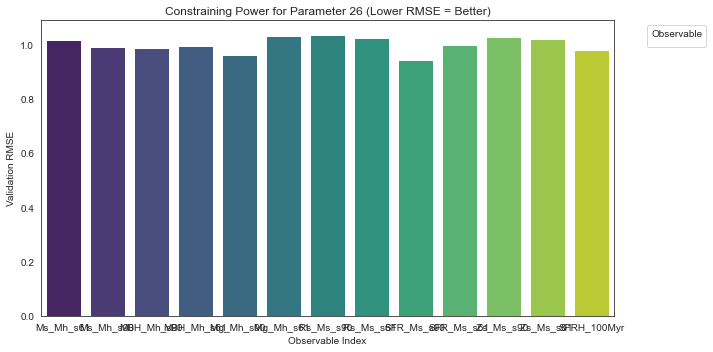

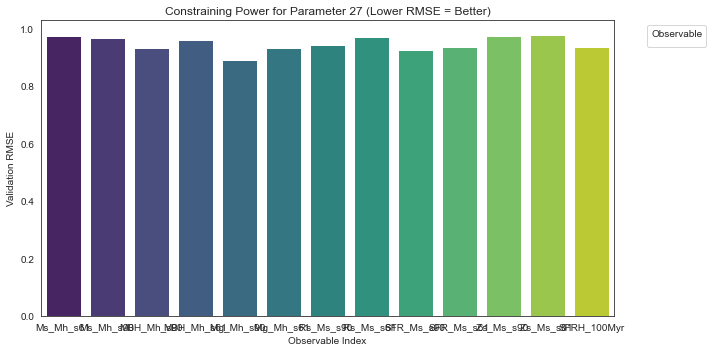

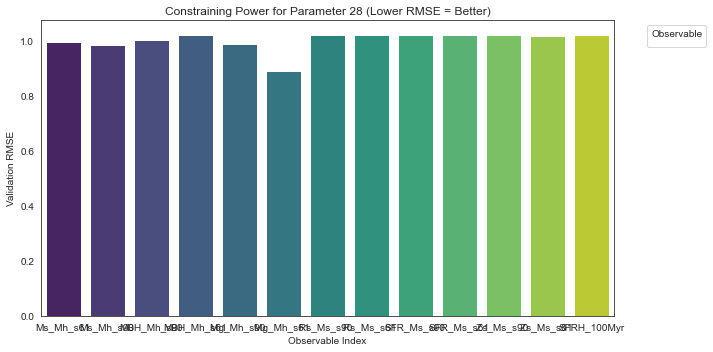

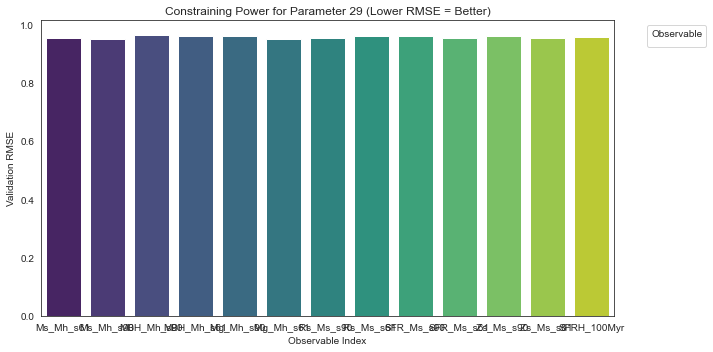

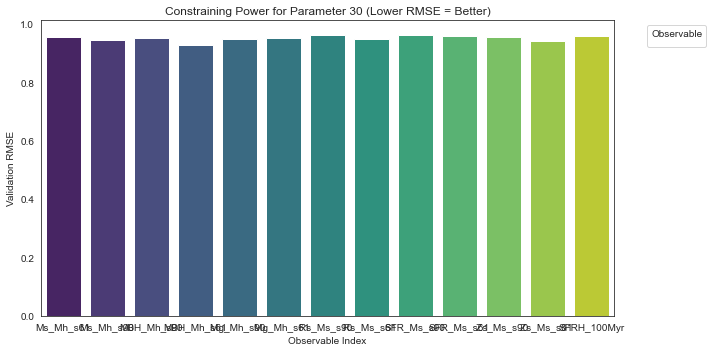

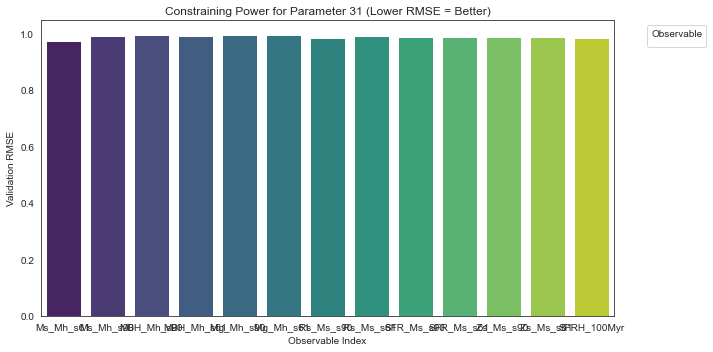

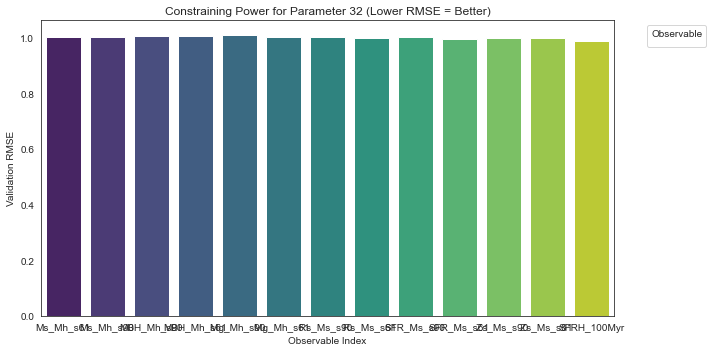

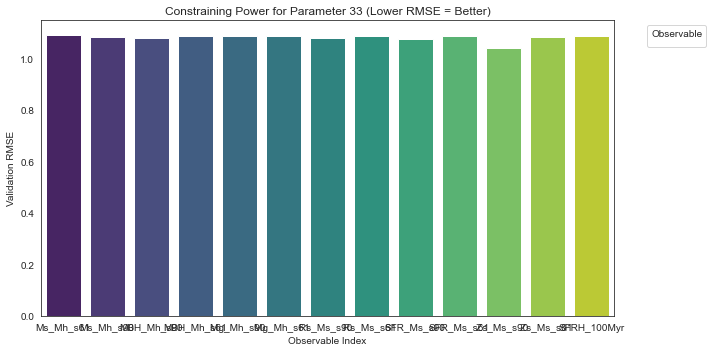

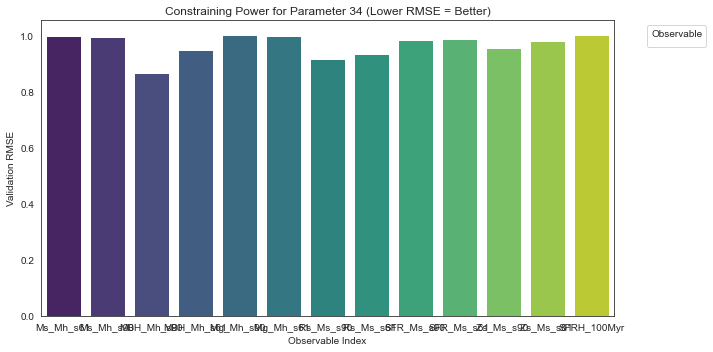

In [80]:
num_parameters = rmse_matrix.shape[1]

for param_idx in range(num_parameters):
    # Filter DataFrame for this parameter
    df_param = df_rmse[df_rmse["Parameter"] == param_idx]

    # Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=df_param,
        x="Observable",
        y="RMSE",
        palette="viridis"
    )
    plt.xlabel("Observable Index")
    plt.ylabel("Validation RMSE")
    plt.legend(title="Observable", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.title(f"Constraining Power for Parameter {param_idx} (Lower RMSE = Better)")
    plt.tight_layout()

    # Save
    #save_path = os.path.join(output_dir, f"constraining_rmse_param_{param_idx}.png")
    #plt.savefig(save_path, dpi=200)
    #plt.close()

    #print(f"Saved RMSE barplot for Parameter {param_idx} to {save_path}")

In [53]:
print(list(observable_block.keys())[1])

Ms_Mh_s90
